In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import preprocessing

### Functions for Calculation Centralities

In [2]:
# Weighted Closeness Centrality
def weighted_closeness(G):
    nodes = list(G.nodes())
    closeness = []
    for i in range(0, len(nodes)):
        close = []
        dist_ij = 0
        for j in range(0, len(nodes)):
            if(nodes[i] == nodes[j]):
                    continue
            else:
                wt , s_path = nx.bidirectional_dijkstra(G, source=nodes[i], target=nodes[j], weight='weight')
                dist_ij = dist_ij + wt
        closeness_i = 1 / dist_ij
        close.append(nodes[i])
        close.append(closeness_i)
        closeness.append(close)
    return closeness

# Weighted Betweenness Centrality
def weighted_betweenness(G):
    nodes = list(G.nodes())
    betweenness = []
    for n in range(0, len(nodes)):
        bett = []
        dist_n = 0
        dist_v = 0
        for s in range(0, len(nodes)):
            for t in range(s+1, len(nodes)):
                if(nodes[n] == nodes[s] or nodes[n] == nodes[t] or nodes[s] == nodes[t]):
                    continue
                else:
                    wt , s_path = nx.bidirectional_dijkstra(G, source=nodes[s], target=nodes[t], weight='weight')
                    if(nodes[n] in s_path):
                        dist_n = dist_n + wt
                    dist_v = dist_v + wt
        betweenness_n = dist_n / dist_v
        bett.append(nodes[n])
        bett.append(betweenness_n)
        betweenness.append(bett)
    return betweenness

# Weighted Edge Contribution Factor
def weighted_ECF(G, W):
    nodes = list(G.nodes())
    ecf = []
    for i in range(0, len(nodes)):
        ecf_ = []
        w_ij = 0
        w_jk = 0
        neighbours_i = list(G.neighbors(nodes[i]))
        for n in range(0, len(neighbours_i)):
            w_ = G.get_edge_data(nodes[i], neighbours_i[n])
            val = w_['weight']
            w_ij = w_ij + val
        nbunch = neighbours_i
        common_neighbours = G.edges(nbunch, data=True)
        common_neighbours = list(common_neighbours)
        for j in range(0, len(common_neighbours)):
            if((common_neighbours[j][0] == nodes[i]) or (common_neighbours[j][1] == nodes[i])):
                continue
            elif(((common_neighbours[j][0] in neighbours_i) == False) or ((common_neighbours[j][1] in neighbours_i) == False )):
                continue
            else:
                w_ = G.get_edge_data(common_neighbours[j][0], common_neighbours[j][1])
                val = w_['weight']
                w_jk = w_jk + val            
            
        w_ecf = (w_ij + w_jk) / W
        ecf_.append(nodes[i])
        ecf_.append(w_ecf)
        ecf.append(ecf_)
    return ecf

def degree(G,W):
    nodes = list(G.nodes())
    w_degree = []
    for i in range(0, len(nodes)):
        deg = []
        nd = nodes[i]
        m_dg = modi_deg(G,nd,W)
        deg.append(nd)
        deg.append(m_dg)
        w_degree.append(deg)
    return w_degree

# New One
def modi_deg(G,i,W_):
    d_i = G.degree(i, weight='weight')
    m_deg = (d_i/W_)/2
    return m_deg

def edge_weighted(G,i):
    all_edges = []
    nbr_i = list(G.neighbors(i))
    for n in range(0,len(nbr_i)):
        j = nbr_i[n]
        adjacent_edges_j = list(G.edges(j))
        all_edges.append(adjacent_edges_j)
    
    all_edges = list(all_edges)
    al_edges = []
    for e in range(0,len(all_edges)):
        al_edges = al_edges + all_edges[e]
    
    rmv_edges = []
    for e_ in range(0, len(al_edges)):
        ed = al_edges[e_]
        if((ed[0] == i) or (ed[1] == i)):
            rmv_edges.append(ed)

    for ed in range(0, len(rmv_edges)):
        rmv_e = rmv_edges[ed]
        al_edges.remove(rmv_e)
        
    if(len(al_edges) == 0):
        return 0
    else:
        refined_edges = list({*map(tuple, map(sorted, al_edges))})
    
        ew_i = 0
        for a in range(0,len(refined_edges)):
            ii = refined_edges[a][0]
            jj = refined_edges[a][1]
            w_jk = G.get_edge_data(ii, jj)
            val = w_jk['weight']
            ew_i = ew_i + val
    
        return ew_i

def weight_of_a_node(G,i,W_1):
    m_deg = modi_deg(G,i,W_1)
    deg_i = G.degree(i, weight='weight')
    edge_wt = edge_weighted(G,i)
    value = (deg_i + edge_wt)/W_1
    weight_value = value * m_deg
    return weight_value


def weighted_cness(G, W):
    nodes = list(G.nodes())
    w_closeness = []
    for i in range(0, len(nodes)):
        closeness = []
        nd = nodes[i]
        weight = weight_of_a_node(G,nd,W)
        closeness.append(nd)
        closeness.append(weight)
        w_closeness.append(closeness)
    return w_closeness
# End of New One


# Total Edge Weight of a Graph
def total_weight_of_G(G):
    edge_weights = list(G.edges.data('weight'))
    W_ = 0
    for e in range(len(edge_weights)):
        w = edge_weights[e][2]
        W_ += w
    return W_


def convert_to_list_value(lst,index):
    l = []
    for i in range(0, len(lst)):
        val = lst[i][index]
        l.append(val)
    return l

### Loading Dataset and Create the Network and its Visualization

### lw_n_1

Name: 
Type: Graph
Number of nodes: 14
Number of edges: 27
Average degree:   3.8571


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


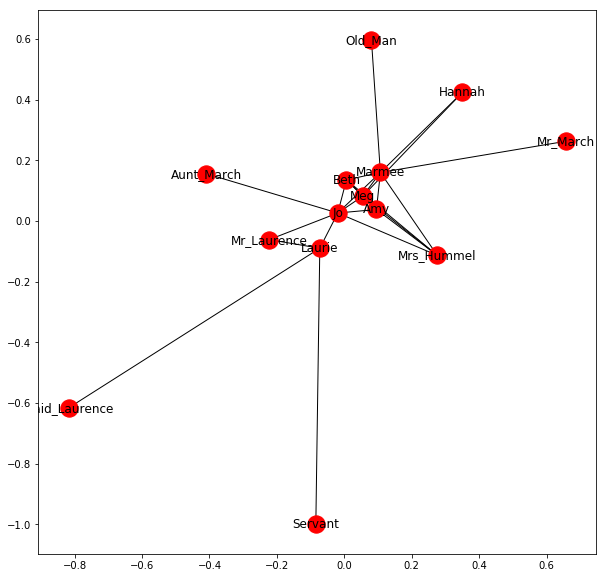

            Nodes  Degree       ECF       NCF
0              Jo   875.0  0.985130  0.327697
1             Amy   338.0  0.790335  0.124810
2             Meg   533.0  0.795539  0.196815
3            Beth   309.0  0.790335  0.114101
4          Marmee   325.0  0.803717  0.120009
5        Mr_March     4.0  0.002974  0.000359
6      Mrs_Hummel    19.0  0.790335  0.007016
7          Hannah     7.0  0.063197  0.001509
8          Laurie   218.0  0.197026  0.052662
9      Aunt_March     9.0  0.014126  0.002152
10        Old_Man     7.0  0.005204  0.000629
11    Mr_Laurence    44.0  0.195539  0.010653
12        Servant     1.0  0.000743  0.000060
13  Maid_Laurence     1.0  0.000743  0.000060
      Degree       ECF       NCF
0   0.735559  0.480437  0.747739
1   0.284136  0.385437  0.284791
2   0.448060  0.387976  0.449093
3   0.259757  0.385437  0.260356
4   0.273207  0.391964  0.273837
5   0.003363  0.001450  0.000820
6   0.015972  0.385437  0.016009
7   0.005884  0.030820  0.003443
8   0.183259 

In [3]:
lw_1 = nx.read_weighted_edgelist('lw_s_1.txt', delimiter=',')
print(nx.info(lw_1))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_1)
plt.show()

#Weighted Centralities
w_deg = lw_1.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_1)  #ECF
w_ecf = weighted_ECF(lw_1, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_1) #NCF
w_ncf = weighted_cness(lw_1,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [4]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.736,0.480,0.748
1,0.284,0.385,0.285
2,0.448,0.388,0.449
3,0.260,0.385,0.260
4,0.273,0.392,0.274
5,0.003,0.001,0.001
6,0.016,0.385,0.016
7,0.006,0.031,0.003
8,0.183,0.096,0.120
9,0.008,0.007,0.005


Text(0, 0.5, 'Values')

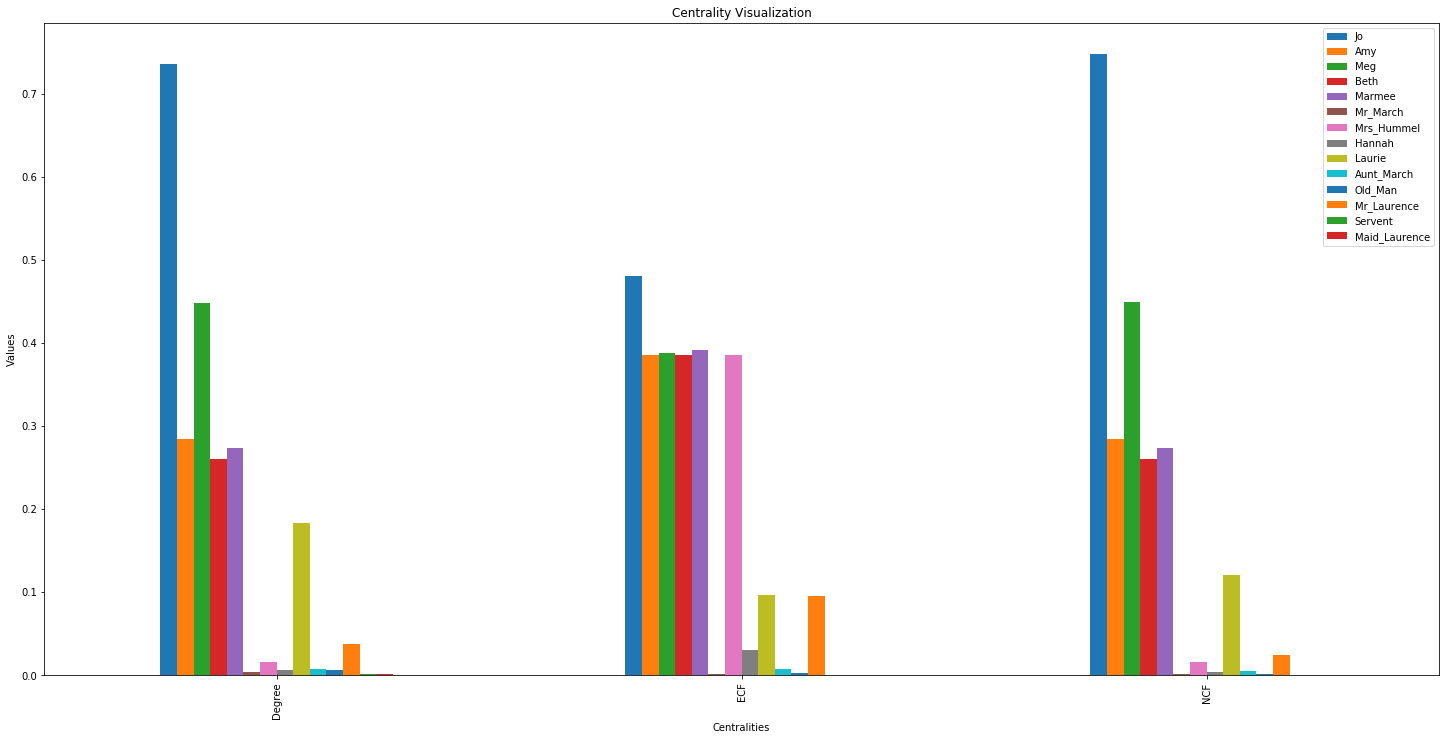

In [4]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Amy":list(df_2.loc[1]),

    "Meg":list(df_2.loc[2]),

    "Beth":list(df_2.loc[3]),
    
    "Marmee":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Mrs_Hummel":list(df_2.loc[6]),
    "Hannah":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Aunt_March":list(df_2.loc[9]),
    "Old_Man":list(df_2.loc[10]),
    "Mr_Laurence":list(df_2.loc[11]),
    "Servent":list(df_2.loc[12]),
    "Maid_Laurence":list(df_2.loc[13])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

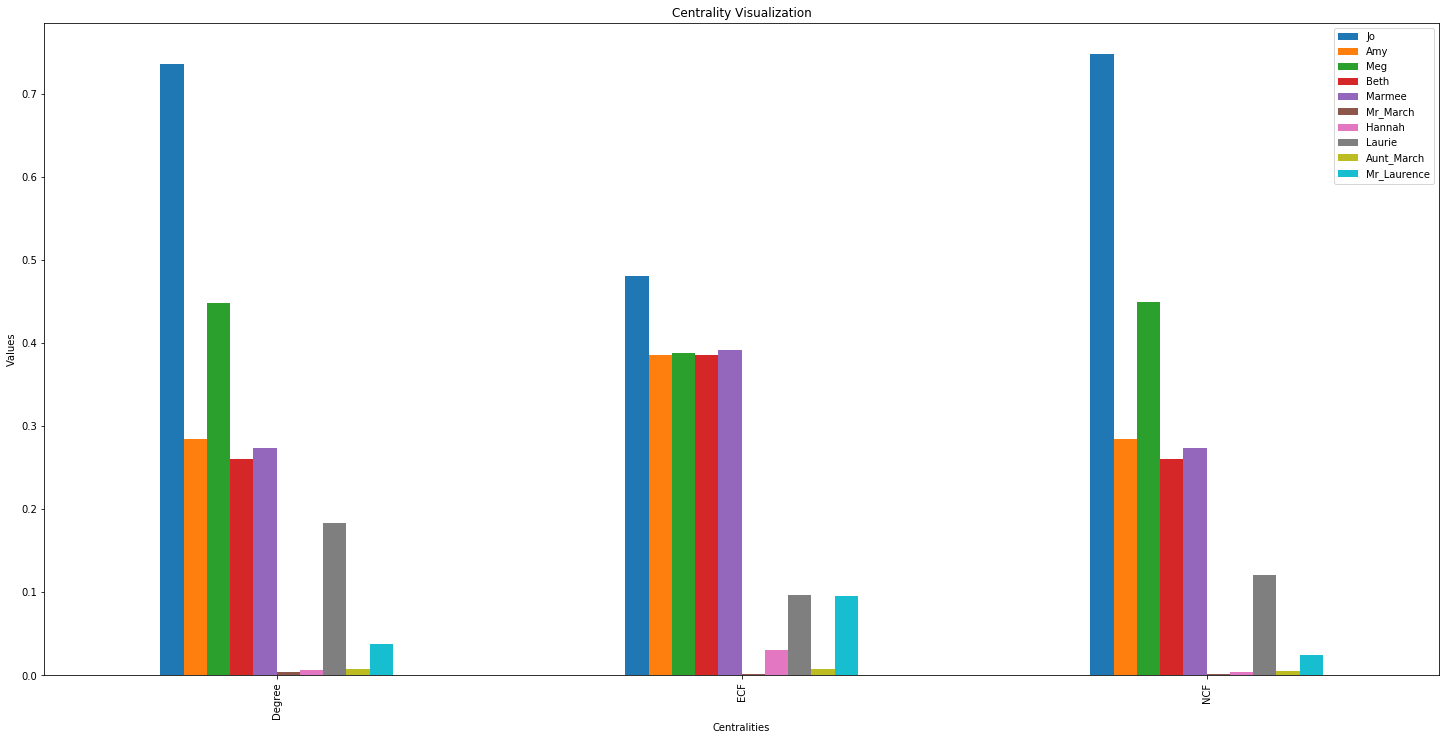

In [5]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Amy":list(df_2.loc[1]),

    "Meg":list(df_2.loc[2]),

    "Beth":list(df_2.loc[3]),
    
    "Marmee":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Aunt_March":list(df_2.loc[9]),
    "Mr_Laurence":list(df_2.loc[11])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

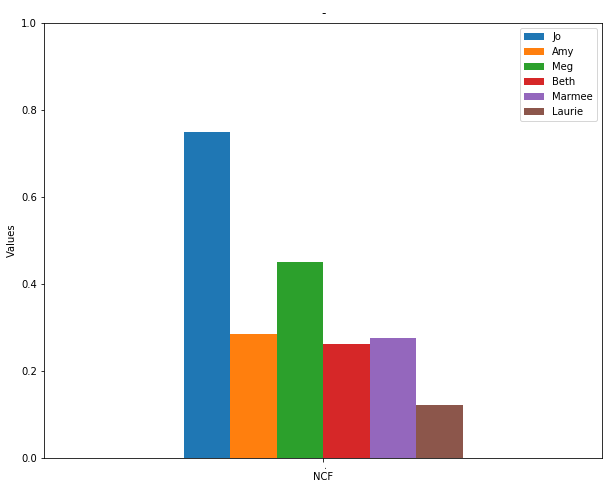

In [6]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[0][2],
    "Amy":df_2.loc[1][2],
    "Meg":df_2.loc[2][2],
    "Beth":df_2.loc[3][2],
    "Marmee":df_2.loc[4][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_2

Name: 
Type: Graph
Number of nodes: 30
Number of edges: 64
Average degree:   4.2667


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


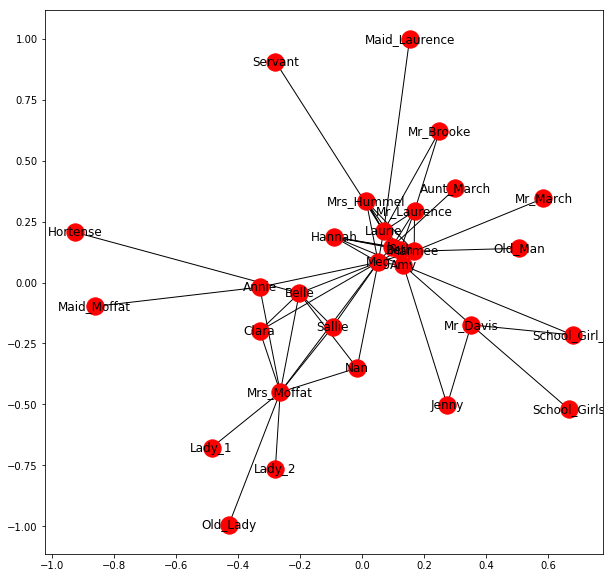

            Nodes  Degree       ECF       NCF
0              Jo  1182.0  0.940212  0.280560
1             Amy   571.0  0.916586  0.134869
2             Meg   863.0  0.933462  0.206848
3            Beth   428.0  0.935873  0.100943
4          Marmee   487.0  0.785439  0.114689
5        Mr_March     4.0  0.001929  0.000226
6      Mrs_Hummel    19.0  0.740598  0.004448
7          Hannah    22.0  0.742044  0.005150
8          Laurie   326.0  0.691900  0.076356
9      Aunt_March     9.0  0.010608  0.001223
10        Old_Man     7.0  0.003375  0.000396
11    Mr_Laurence    72.0  0.349084  0.014889
12        Servant     1.0  0.000482  0.000038
13  Maid_Laurence     1.0  0.000482  0.000038
14      Mr_Brooke     6.0  0.006268  0.000273
15       Mr_Davis    26.0  0.013983  0.001750
16          Jenny     4.0  0.010608  0.000269
17  School_Girl_1     4.0  0.010608  0.000269
18   School_Girls     3.0  0.001446  0.000009
19            Nan     6.0  0.013983  0.000623
20          Clara     8.0  0.01494

In [5]:
lw_2 = nx.read_weighted_edgelist('lw_s_2.txt', delimiter=',')
print(nx.info(lw_2))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_2)
plt.show()

#Weighted Centralities
w_deg = lw_2.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_2)  #ECF
w_ecf = weighted_ECF(lw_2, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_2) #NCF
w_ncf = weighted_cness(lw_2,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [6]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.682,0.391,0.682
1,0.329,0.381,0.328
2,0.498,0.388,0.503
3,0.247,0.389,0.245
4,0.281,0.326,0.279
5,0.002,0.001,0.001
6,0.011,0.308,0.011
7,0.013,0.308,0.013
8,0.188,0.288,0.186
9,0.005,0.004,0.003


Text(0, 0.5, 'Values')

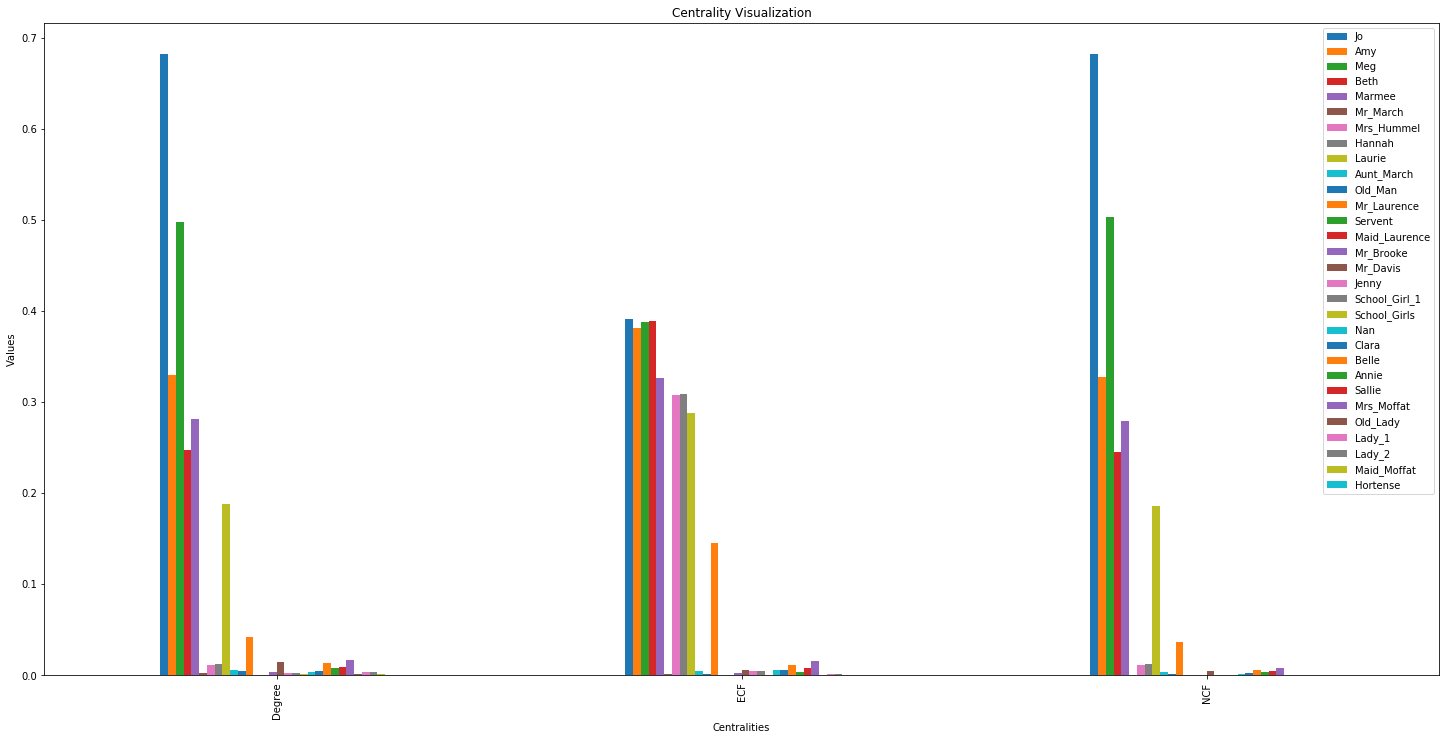

In [8]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Amy":list(df_2.loc[1]),

    "Meg":list(df_2.loc[2]),

    "Beth":list(df_2.loc[3]),
    
    "Marmee":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Mrs_Hummel":list(df_2.loc[6]),
    "Hannah":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Aunt_March":list(df_2.loc[9]),
    "Old_Man":list(df_2.loc[10]),
    "Mr_Laurence":list(df_2.loc[11]),
    "Servent":list(df_2.loc[12]),
    "Maid_Laurence":list(df_2.loc[13]),
    "Mr_Brooke":list(df_2.loc[14]),
    "Mr_Davis":list(df_2.loc[15]),
    "Jenny":list(df_2.loc[16]),
    "School_Girl_1":list(df_2.loc[17]),
    "School_Girls":list(df_2.loc[18]),
    "Nan":list(df_2.loc[19]),
    "Clara":list(df_2.loc[20]),
    "Belle":list(df_2.loc[21]),
    "Annie":list(df_2.loc[22]),
    "Sallie":list(df_2.loc[23]),
    "Mrs_Moffat":list(df_2.loc[24]),
    "Old_Lady":list(df_2.loc[25]),
    "Lady_1":list(df_2.loc[26]),
    "Lady_2":list(df_2.loc[27]),
    "Maid_Moffat":list(df_2.loc[28]),
    "Hortense":list(df_2.loc[29])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

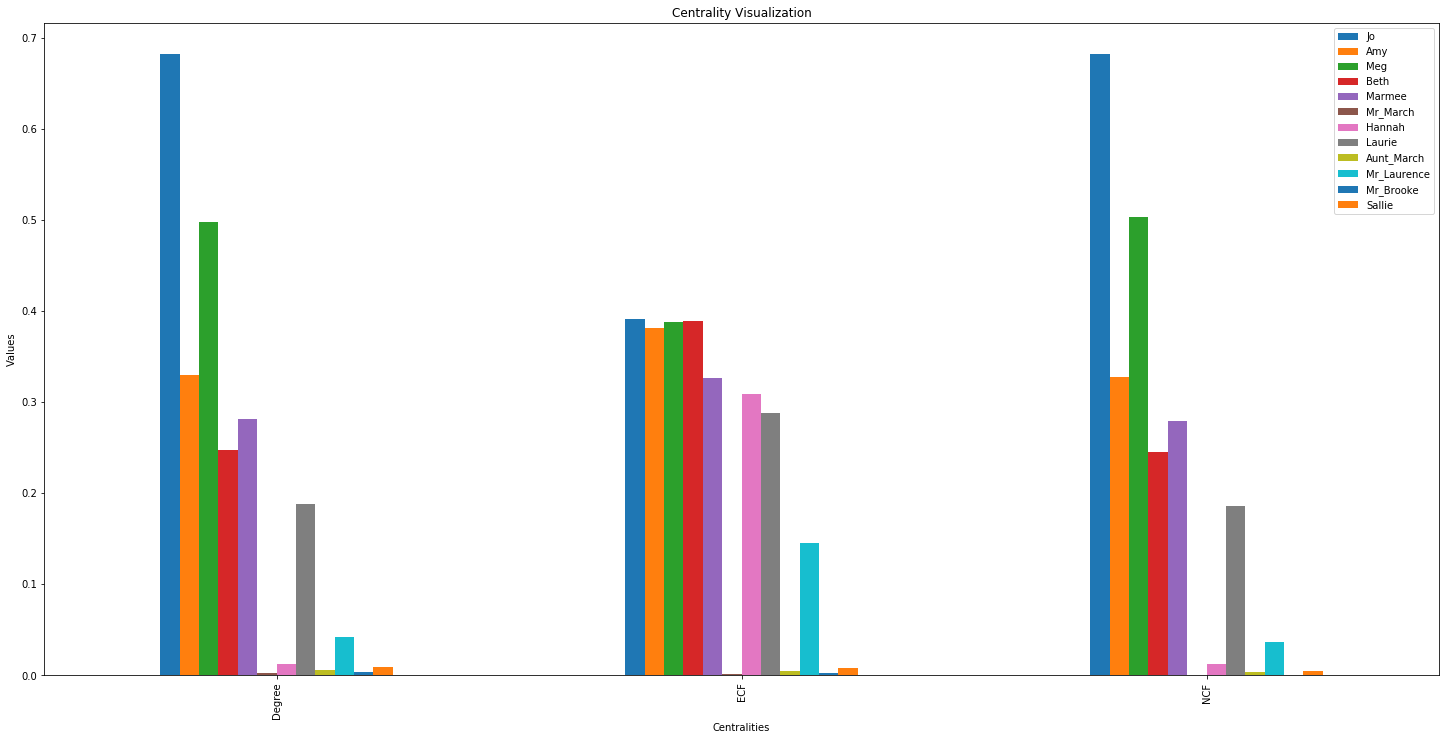

In [9]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Amy":list(df_2.loc[1]),
    "Meg":list(df_2.loc[2]),
    "Beth":list(df_2.loc[3]),
    "Marmee":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Aunt_March":list(df_2.loc[9]),
    "Mr_Laurence":list(df_2.loc[11]),
    "Mr_Brooke":list(df_2.loc[14]),
    "Sallie":list(df_2.loc[23])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

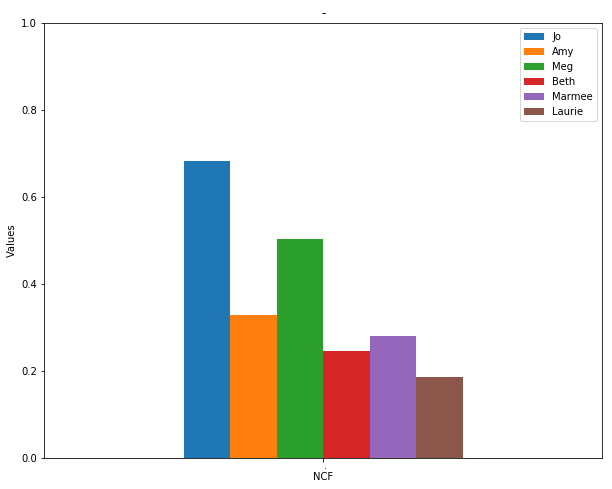

In [10]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[0][2],
    "Amy":df_2.loc[1][2],
    "Meg":df_2.loc[2][2],
    "Beth":df_2.loc[3][2],
    "Marmee":df_2.loc[4][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_3

Name: 
Type: Graph
Number of nodes: 35
Number of edges: 119
Average degree:   6.8000


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


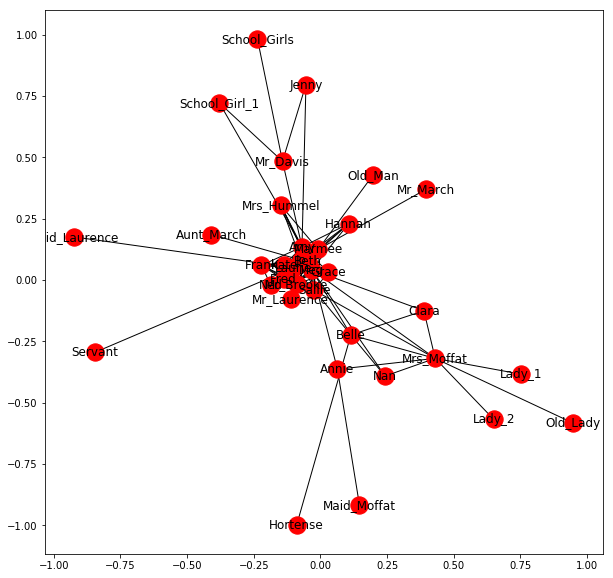

            Nodes  Degree       ECF           NCF
0              Jo  1964.0  0.973923  2.339166e-01
1             Amy   894.0  0.961005  1.061703e-01
2             Meg  1443.0  0.967225  1.723186e-01
3            Beth   791.0  0.948565  9.375707e-02
4          Marmee   682.0  0.744976  7.476769e-02
5        Mr_March     4.0  0.001196  7.795151e-05
6      Mrs_Hummel    19.0  0.529426  1.946498e-03
7          Hannah    25.0  0.530861  2.561182e-03
8          Laurie  1043.0  0.961722  1.238355e-01
9      Aunt_March     9.0  0.006938  5.006754e-04
10        Old_Man     7.0  0.001914  1.364151e-04
11    Mr_Laurence    72.0  0.317225  7.180467e-03
12        Servant     1.0  0.001914  2.964676e-05
13  Maid_Laurence     1.0  0.001914  2.964676e-05
14      Mr_Brooke   257.0  0.802392  3.032978e-02
15       Mr_Davis    26.0  0.006938  6.711156e-04
16          Jenny     4.0  0.005263  1.032486e-04
17  School_Girl_1     4.0  0.005263  1.032486e-04
18   School_Girls     3.0  0.000718  2.232092e-06


In [7]:
lw_3 = nx.read_weighted_edgelist('lw_s_3.txt', delimiter=',')
print(nx.info(lw_3))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_3)
plt.show()

#Weighted Centralities
w_deg = lw_3.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_3)  #ECF
w_ecf = weighted_ECF(lw_3, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_3) #NCF
w_ncf = weighted_cness(lw_3,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [8]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.648,0.309,0.651
1,0.295,0.305,0.295
2,0.476,0.307,0.480
3,0.261,0.301,0.261
4,0.225,0.236,0.208
5,0.001,0.000,0.000
6,0.006,0.168,0.005
7,0.008,0.168,0.007
8,0.344,0.305,0.345
9,0.003,0.002,0.001


Text(0, 0.5, 'Values')

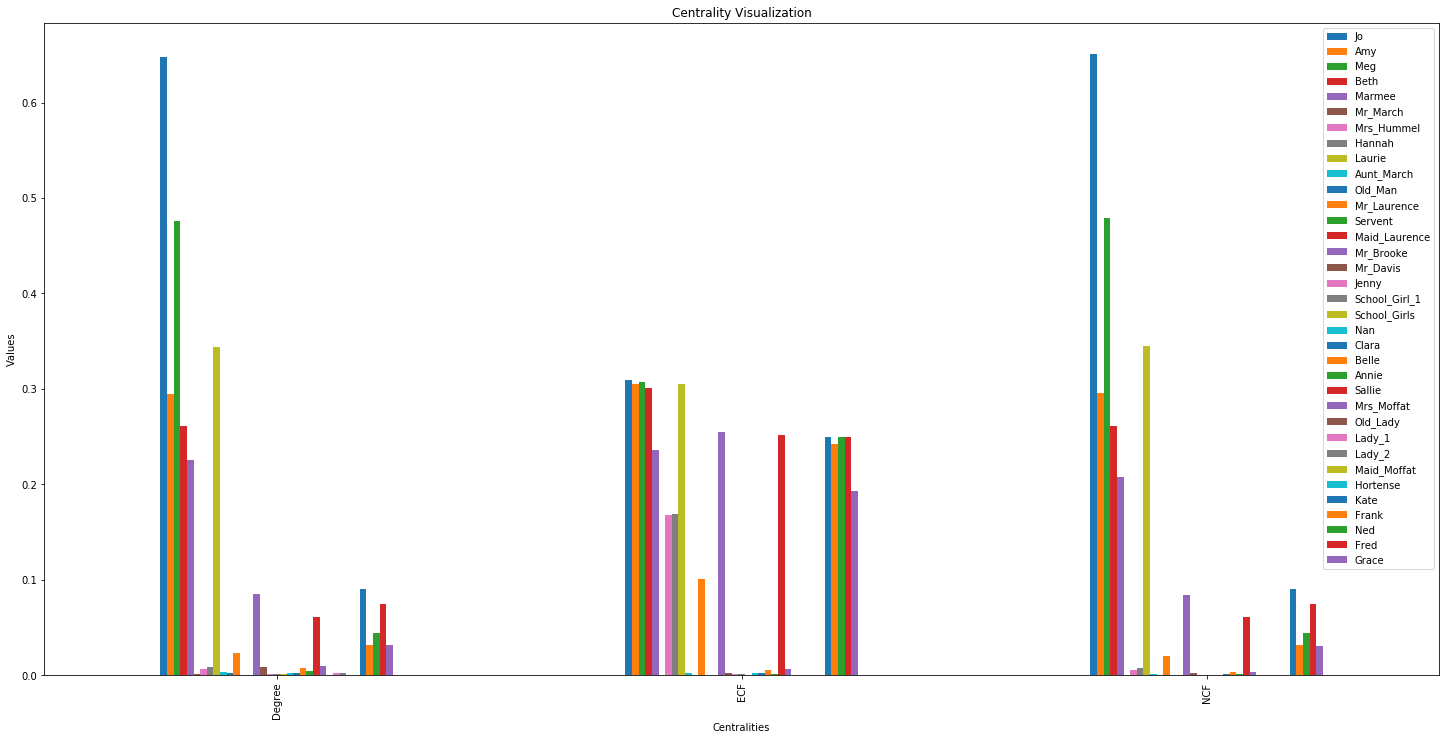

In [12]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Amy":list(df_2.loc[1]),
    "Meg":list(df_2.loc[2]),
    "Beth":list(df_2.loc[3]),
    "Marmee":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Mrs_Hummel":list(df_2.loc[6]),
    "Hannah":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Aunt_March":list(df_2.loc[9]),
    "Old_Man":list(df_2.loc[10]),
    "Mr_Laurence":list(df_2.loc[11]),
    "Servent":list(df_2.loc[12]),
    "Maid_Laurence":list(df_2.loc[13]),
    "Mr_Brooke":list(df_2.loc[14]),
    "Mr_Davis":list(df_2.loc[15]),
    "Jenny":list(df_2.loc[16]),
    "School_Girl_1":list(df_2.loc[17]),
    "School_Girls":list(df_2.loc[18]),
    "Nan":list(df_2.loc[19]),
    "Clara":list(df_2.loc[20]),
    "Belle":list(df_2.loc[21]),
    "Annie":list(df_2.loc[22]),
    "Sallie":list(df_2.loc[23]),
    "Mrs_Moffat":list(df_2.loc[24]),
    "Old_Lady":list(df_2.loc[25]),
    "Lady_1":list(df_2.loc[26]),
    "Lady_2":list(df_2.loc[27]),
    "Maid_Moffat":list(df_2.loc[28]),
    "Hortense":list(df_2.loc[29]),
    "Kate":list(df_2.loc[30]),
    "Frank":list(df_2.loc[31]),
    "Ned":list(df_2.loc[32]),
    "Fred":list(df_2.loc[33]),
    "Grace":list(df_2.loc[34])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

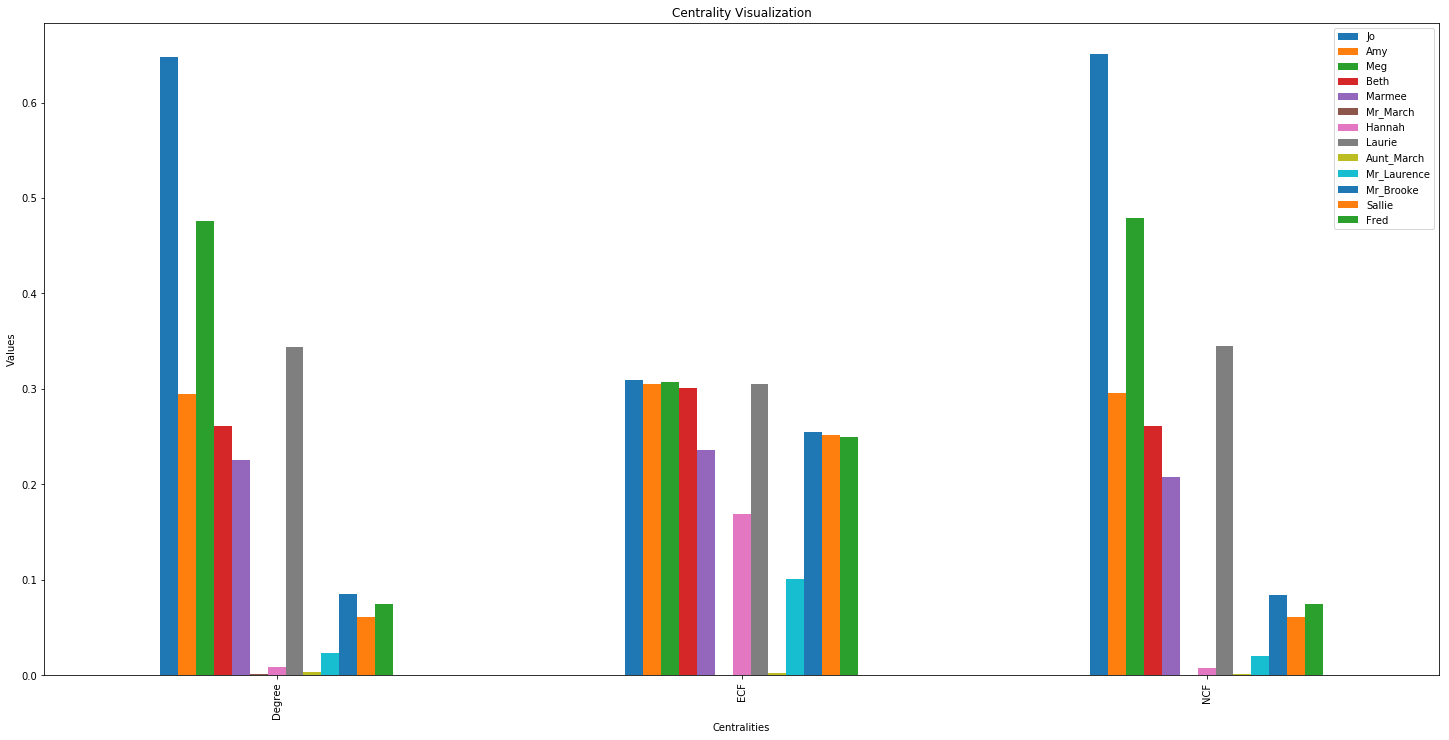

In [13]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Amy":list(df_2.loc[1]),
    "Meg":list(df_2.loc[2]),
    "Beth":list(df_2.loc[3]),
    "Marmee":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Aunt_March":list(df_2.loc[9]),
    "Mr_Laurence":list(df_2.loc[11]),
    "Mr_Brooke":list(df_2.loc[14]),
    "Sallie":list(df_2.loc[23]),
    "Fred":list(df_2.loc[33])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

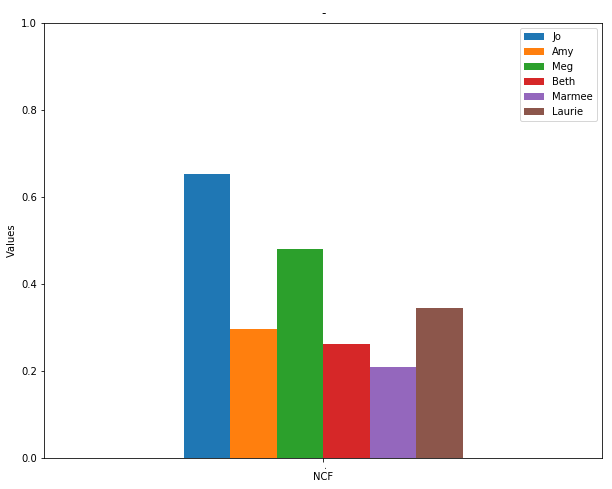

In [14]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[0][2],
    "Amy":df_2.loc[1][2],
    "Meg":df_2.loc[2][2],
    "Beth":df_2.loc[3][2],
    "Marmee":df_2.loc[4][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_4

Name: 
Type: Graph
Number of nodes: 37
Number of edges: 124
Average degree:   6.7027


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


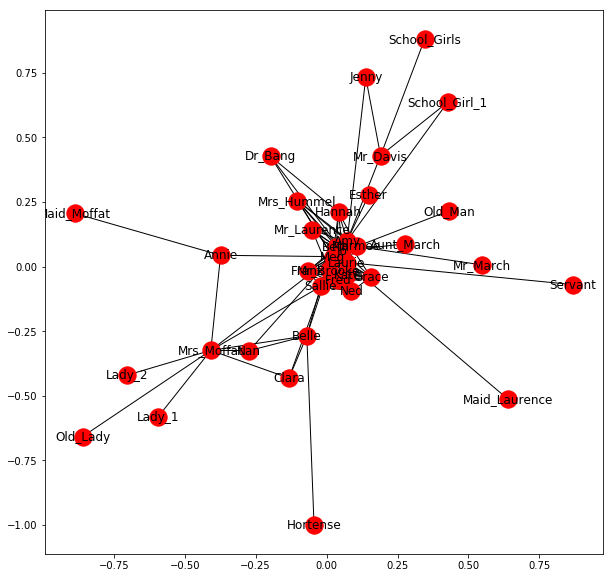

            Nodes  Degree       ECF           NCF
0              Jo  2256.0  0.970450  2.406625e-01
1             Amy  1021.0  0.961242  1.086125e-01
2             Meg  1545.0  0.961670  1.651696e-01
3            Beth   872.0  0.943897  9.260219e-02
4          Marmee   846.0  0.792291  8.603955e-02
5        Mr_March     4.0  0.001285  7.739959e-05
6      Mrs_Hummel    19.0  0.533191  1.772464e-03
7          Hannah    52.0  0.541113  4.852148e-03
8          Laurie  1181.0  0.950107  1.255790e-01
9      Aunt_March    22.0  0.009208  1.127292e-03
10        Old_Man     7.0  0.001927  1.354493e-04
11    Mr_Laurence    72.0  0.334047  6.483958e-03
12        Servant     1.0  0.001713  2.691562e-05
13  Maid_Laurence     1.0  0.001713  2.691562e-05
14      Mr_Brooke   259.0  0.949679  2.749861e-02
15       Mr_Davis    26.0  0.006210  6.133734e-04
16          Jenny     4.0  0.004711  9.436514e-05
17  School_Girl_1     4.0  0.004711  9.436514e-05
18   School_Girls     3.0  0.000642  1.788261e-06


In [9]:
lw_4 = nx.read_weighted_edgelist('lw_s_4.txt', delimiter=',')
print(nx.info(lw_4))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_4)
plt.show()

#Weighted Centralities
w_deg = lw_4.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_4)  #ECF
w_ecf = weighted_ECF(lw_4, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_4) #NCF
w_ncf = weighted_cness(lw_4,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [10]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.660,0.307,0.663
1,0.299,0.304,0.299
2,0.452,0.304,0.455
3,0.255,0.298,0.255
4,0.248,0.250,0.237
5,0.001,0.000,0.000
6,0.006,0.168,0.005
7,0.015,0.171,0.013
8,0.346,0.300,0.346
9,0.006,0.003,0.003


Text(0, 0.5, 'Values')

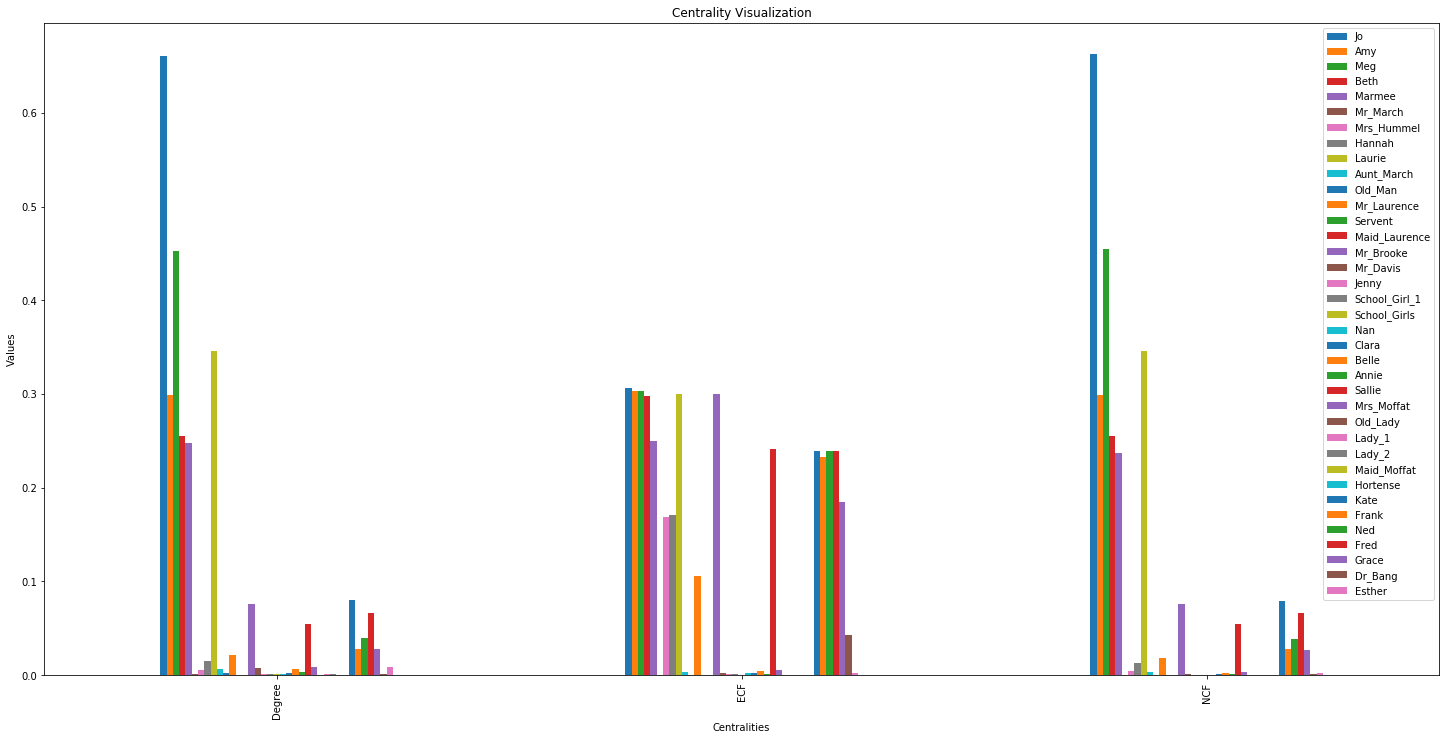

In [16]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Amy":list(df_2.loc[1]),
    "Meg":list(df_2.loc[2]),
    "Beth":list(df_2.loc[3]),
    "Marmee":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Mrs_Hummel":list(df_2.loc[6]),
    "Hannah":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Aunt_March":list(df_2.loc[9]),
    "Old_Man":list(df_2.loc[10]),
    "Mr_Laurence":list(df_2.loc[11]),
    "Servent":list(df_2.loc[12]),
    "Maid_Laurence":list(df_2.loc[13]),
    "Mr_Brooke":list(df_2.loc[14]),
    "Mr_Davis":list(df_2.loc[15]),
    "Jenny":list(df_2.loc[16]),
    "School_Girl_1":list(df_2.loc[17]),
    "School_Girls":list(df_2.loc[18]),
    "Nan":list(df_2.loc[19]),
    "Clara":list(df_2.loc[20]),
    "Belle":list(df_2.loc[21]),
    "Annie":list(df_2.loc[22]),
    "Sallie":list(df_2.loc[23]),
    "Mrs_Moffat":list(df_2.loc[24]),
    "Old_Lady":list(df_2.loc[25]),
    "Lady_1":list(df_2.loc[26]),
    "Lady_2":list(df_2.loc[27]),
    "Maid_Moffat":list(df_2.loc[28]),
    "Hortense":list(df_2.loc[29]),
    "Kate":list(df_2.loc[30]),
    "Frank":list(df_2.loc[31]),
    "Ned":list(df_2.loc[32]),
    "Fred":list(df_2.loc[33]),
    "Grace":list(df_2.loc[34]),
    "Dr_Bang":list(df_2.loc[35]),
    "Esther":list(df_2.loc[36])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

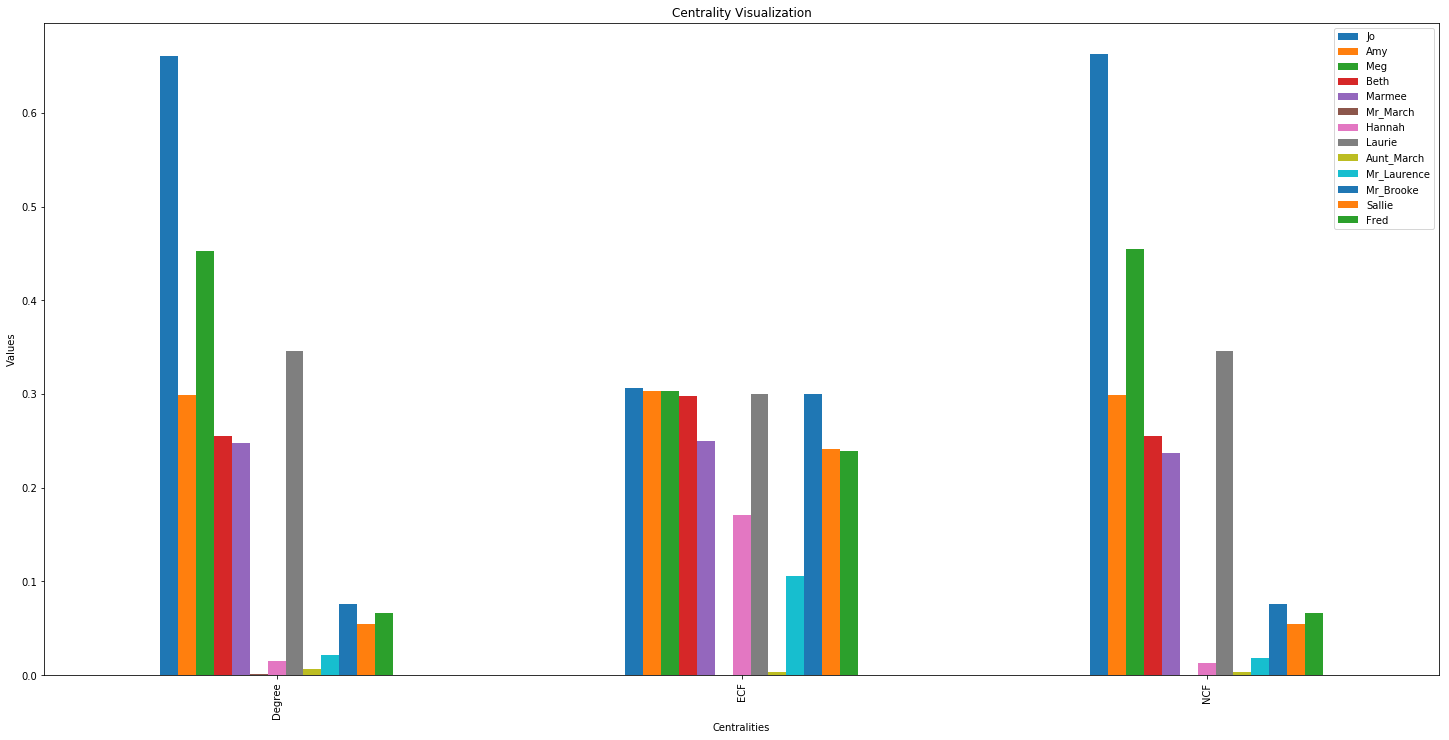

In [17]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Amy":list(df_2.loc[1]),
    "Meg":list(df_2.loc[2]),
    "Beth":list(df_2.loc[3]),
    "Marmee":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Aunt_March":list(df_2.loc[9]),
    "Mr_Laurence":list(df_2.loc[11]),
    "Mr_Brooke":list(df_2.loc[14]),
    "Sallie":list(df_2.loc[23]),
    "Fred":list(df_2.loc[33])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

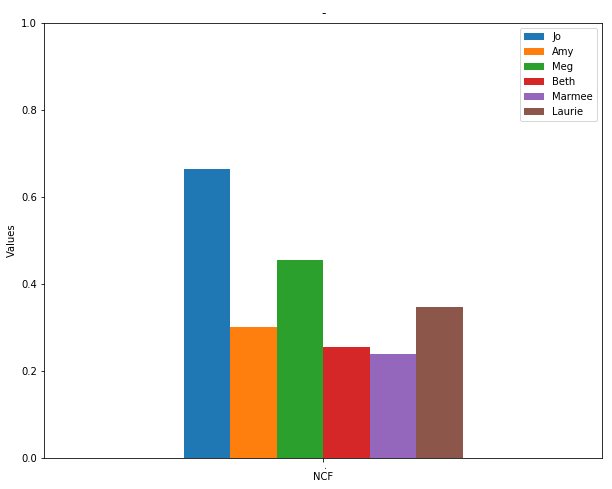

In [18]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[0][2],
    "Amy":df_2.loc[1][2],
    "Meg":df_2.loc[2][2],
    "Beth":df_2.loc[3][2],
    "Marmee":df_2.loc[4][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_5

Name: 
Type: Graph
Number of nodes: 37
Number of edges: 131
Average degree:   7.0811


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


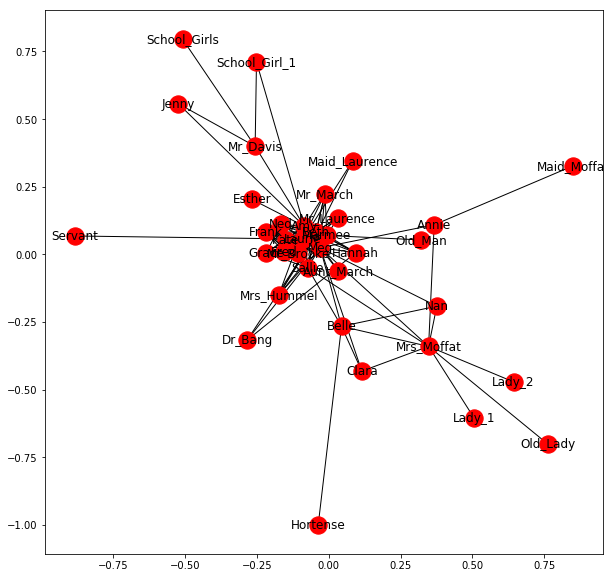

            Nodes  Degree       ECF           NCF
0              Jo  2546.0  0.974150  2.468476e-01
1             Amy  1047.0  0.940719  1.011758e-01
2             Meg  1753.0  0.957434  1.701278e-01
3            Beth   899.0  0.935860  8.672110e-02
4          Marmee   901.0  0.797473  8.357838e-02
5        Mr_March    55.0  0.721477  4.973079e-03
6      Mrs_Hummel    19.0  0.510010  1.629688e-03
7          Hannah    53.0  0.517396  4.546972e-03
8          Laurie  1298.0  0.943246  1.253573e-01
9      Aunt_March    84.0  0.144801  5.772198e-03
10        Old_Man     7.0  0.001749  1.188658e-04
11    Mr_Laurence   128.0  0.343246  1.043012e-02
12        Servant     1.0  0.001555  2.438515e-05
13  Maid_Laurence    11.0  0.134305  6.573980e-04
14      Mr_Brooke   306.0  0.930224  2.951219e-02
15       Mr_Davis    26.0  0.005831  5.176226e-04
16          Jenny     4.0  0.004470  7.963424e-05
17  School_Girl_1     4.0  0.004470  7.963424e-05
18   School_Girls     3.0  0.000583  1.473309e-06


In [11]:
lw_5 = nx.read_weighted_edgelist('lw_s_5.txt', delimiter=',')
print(nx.info(lw_5))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_5)
plt.show()

#Weighted Centralities
w_deg = lw_5.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_5)  #ECF
w_ecf = weighted_ECF(lw_5, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_5) #NCF
w_ncf = weighted_cness(lw_5,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [12]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.674,0.304,0.676
1,0.277,0.294,0.277
2,0.464,0.299,0.466
3,0.238,0.292,0.238
4,0.238,0.249,0.229
5,0.015,0.225,0.014
6,0.005,0.159,0.004
7,0.014,0.162,0.012
8,0.343,0.294,0.343
9,0.022,0.045,0.016


Text(0, 0.5, 'Values')

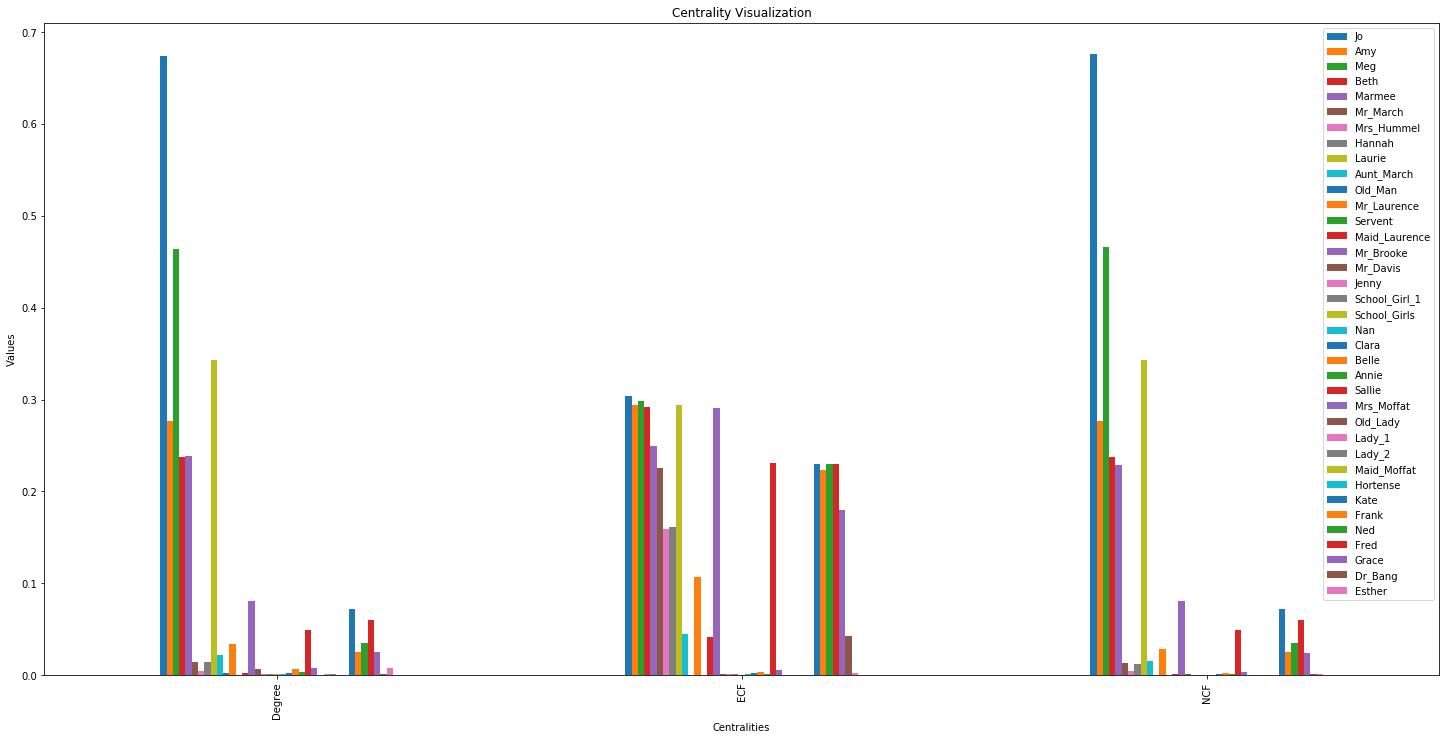

In [20]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Amy":list(df_2.loc[1]),
    "Meg":list(df_2.loc[2]),
    "Beth":list(df_2.loc[3]),
    "Marmee":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Mrs_Hummel":list(df_2.loc[6]),
    "Hannah":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Aunt_March":list(df_2.loc[9]),
    "Old_Man":list(df_2.loc[10]),
    "Mr_Laurence":list(df_2.loc[11]),
    "Servent":list(df_2.loc[12]),
    "Maid_Laurence":list(df_2.loc[13]),
    "Mr_Brooke":list(df_2.loc[14]),
    "Mr_Davis":list(df_2.loc[15]),
    "Jenny":list(df_2.loc[16]),
    "School_Girl_1":list(df_2.loc[17]),
    "School_Girls":list(df_2.loc[18]),
    "Nan":list(df_2.loc[19]),
    "Clara":list(df_2.loc[20]),
    "Belle":list(df_2.loc[21]),
    "Annie":list(df_2.loc[22]),
    "Sallie":list(df_2.loc[23]),
    "Mrs_Moffat":list(df_2.loc[24]),
    "Old_Lady":list(df_2.loc[25]),
    "Lady_1":list(df_2.loc[26]),
    "Lady_2":list(df_2.loc[27]),
    "Maid_Moffat":list(df_2.loc[28]),
    "Hortense":list(df_2.loc[29]),
    "Kate":list(df_2.loc[30]),
    "Frank":list(df_2.loc[31]),
    "Ned":list(df_2.loc[32]),
    "Fred":list(df_2.loc[33]),
    "Grace":list(df_2.loc[34]),
    "Dr_Bang":list(df_2.loc[35]),
    "Esther":list(df_2.loc[36])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

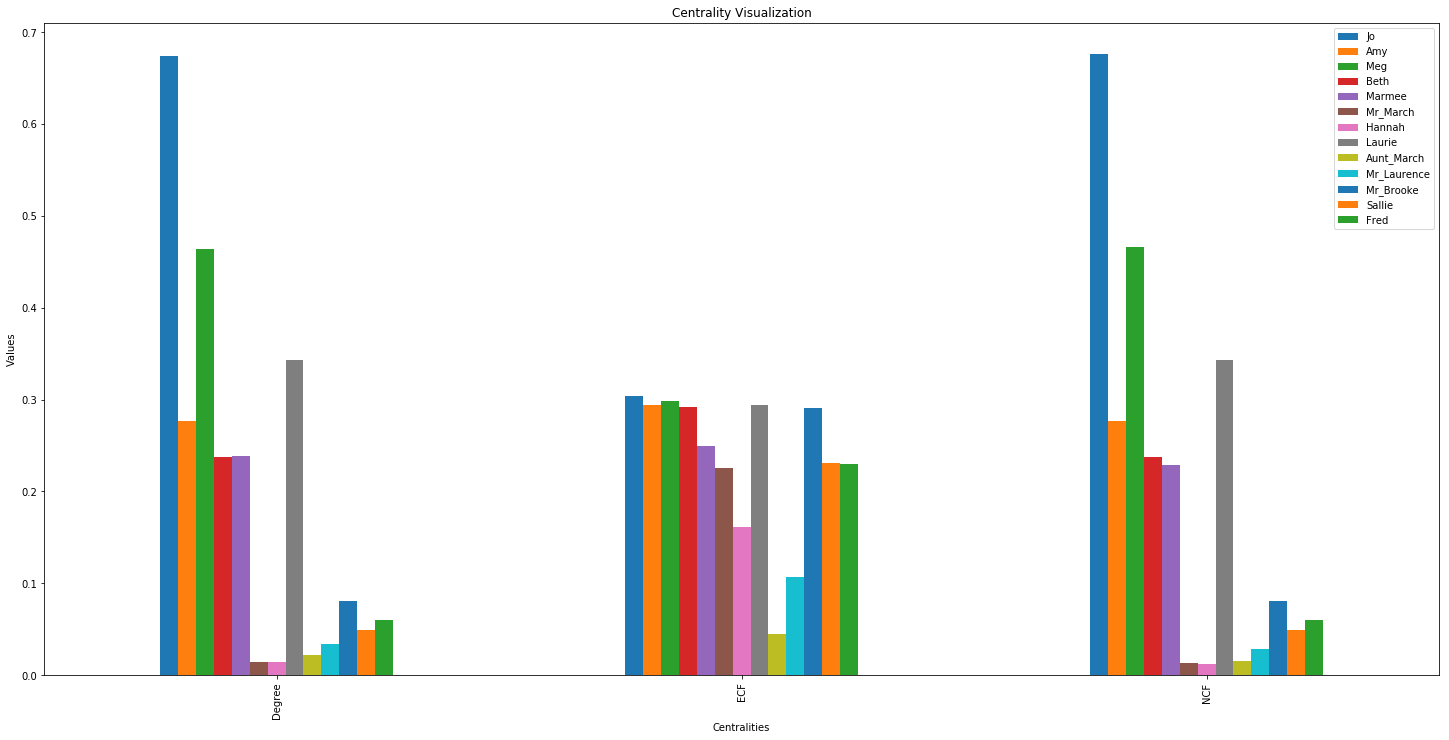

In [21]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Amy":list(df_2.loc[1]),
    "Meg":list(df_2.loc[2]),
    "Beth":list(df_2.loc[3]),
    "Marmee":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Aunt_March":list(df_2.loc[9]),
    "Mr_Laurence":list(df_2.loc[11]),
    "Mr_Brooke":list(df_2.loc[14]),
    "Sallie":list(df_2.loc[23]),
    "Fred":list(df_2.loc[33])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

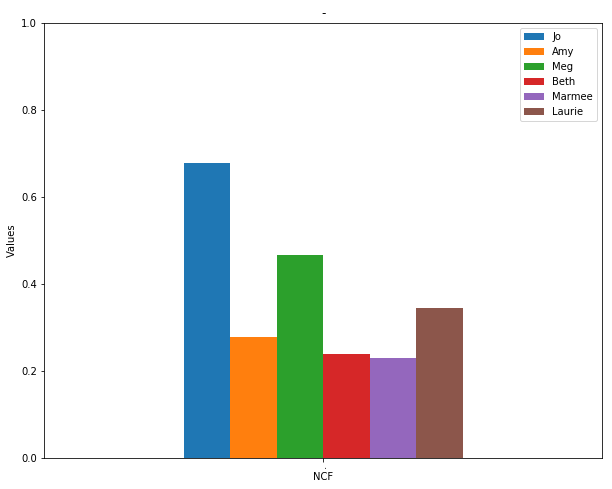

In [22]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[0][2],
    "Amy":df_2.loc[1][2],
    "Meg":df_2.loc[2][2],
    "Beth":df_2.loc[3][2],
    "Marmee":df_2.loc[4][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_6

Name: 
Type: Graph
Number of nodes: 43
Number of edges: 140
Average degree:   6.5116


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


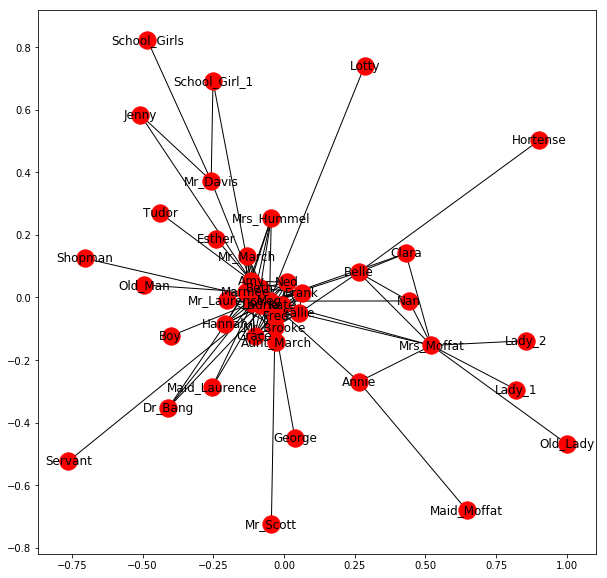

            Nodes  Degree       ECF           NCF
0              Jo  2719.0  0.973007  2.425069e-01
1             Amy  1160.0  0.956024  1.031635e-01
2             Meg  1937.0  0.955846  1.730700e-01
3            Beth   917.0  0.934394  8.140604e-02
4          Marmee   997.0  0.806757  8.538568e-02
5        Mr_March    76.0  0.721130  6.346117e-03
6      Mrs_Hummel    19.0  0.497497  1.507597e-03
7          Hannah    64.0  0.719700  5.345121e-03
8          Laurie  1454.0  0.950483  1.292405e-01
9      Aunt_March    92.0  0.266714  7.066218e-03
10        Old_Man     7.0  0.001609  1.112875e-04
11    Mr_Laurence   130.0  0.339650  9.783389e-03
12        Servant     1.0  0.001430  2.312031e-05
13  Maid_Laurence    11.0  0.140865  5.968778e-04
14      Mr_Brooke   391.0  0.941545  3.470451e-02
15       Mr_Davis    26.0  0.005542  4.843920e-04
16          Jenny     4.0  0.004290  7.452185e-05
17  School_Girl_1     4.0  0.004290  7.452185e-05
18   School_Girls     3.0  0.000536  1.246292e-06


In [13]:
lw_6 = nx.read_weighted_edgelist('lw_s_6.txt', delimiter=',')
print(nx.info(lw_6))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_6)
plt.show()

#Weighted Centralities
w_deg = lw_6.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_6)  #ECF
w_ecf = weighted_ECF(lw_6, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_6) #NCF
w_ncf = weighted_cness(lw_6,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [14]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.663,0.299,0.665
1,0.283,0.294,0.283
2,0.472,0.294,0.475
3,0.224,0.288,0.223
4,0.243,0.248,0.234
5,0.019,0.222,0.017
6,0.005,0.153,0.004
7,0.016,0.221,0.015
8,0.354,0.292,0.354
9,0.022,0.082,0.019


Text(0, 0.5, 'Values')

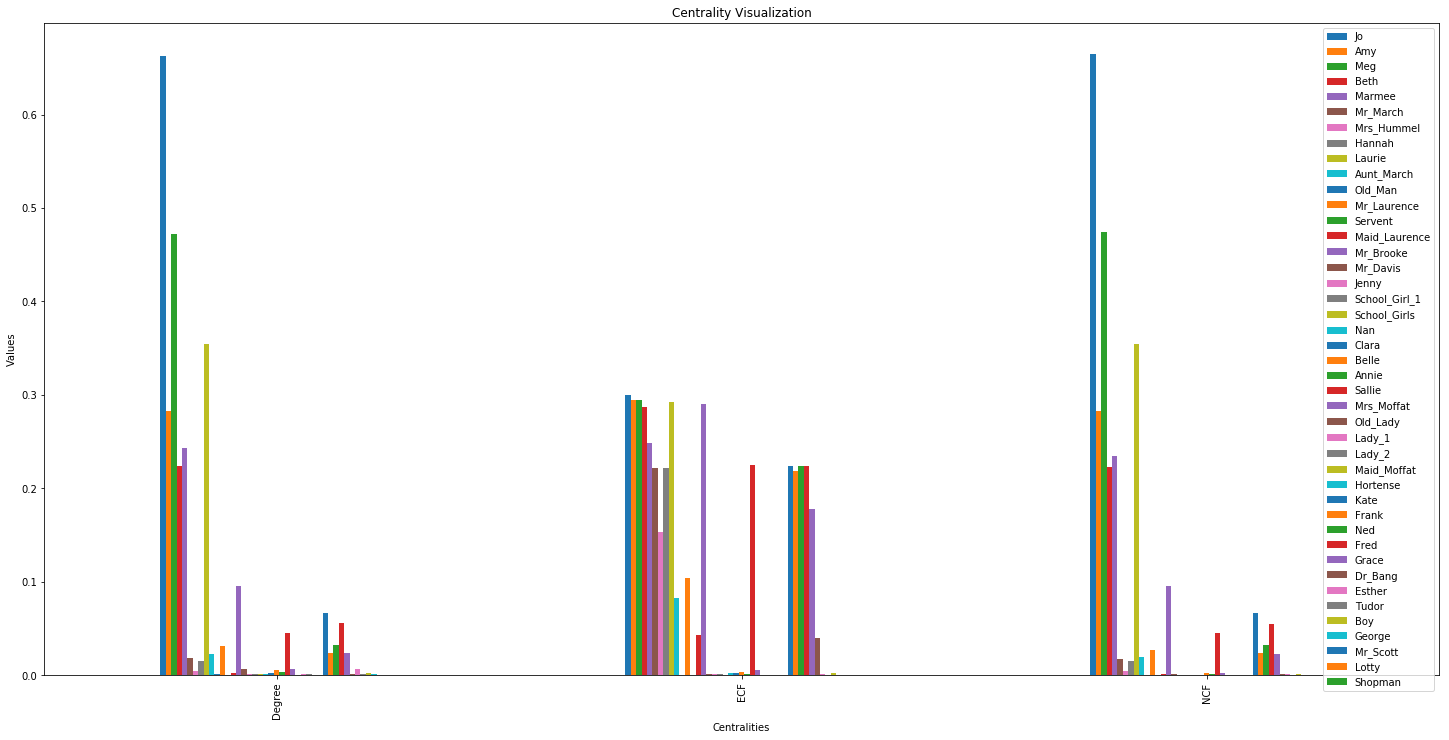

In [24]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Amy":list(df_2.loc[1]),
    "Meg":list(df_2.loc[2]),
    "Beth":list(df_2.loc[3]),
    "Marmee":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Mrs_Hummel":list(df_2.loc[6]),
    "Hannah":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Aunt_March":list(df_2.loc[9]),
    "Old_Man":list(df_2.loc[10]),
    "Mr_Laurence":list(df_2.loc[11]),
    "Servent":list(df_2.loc[12]),
    "Maid_Laurence":list(df_2.loc[13]),
    "Mr_Brooke":list(df_2.loc[14]),
    "Mr_Davis":list(df_2.loc[15]),
    "Jenny":list(df_2.loc[16]),
    "School_Girl_1":list(df_2.loc[17]),
    "School_Girls":list(df_2.loc[18]),
    "Nan":list(df_2.loc[19]),
    "Clara":list(df_2.loc[20]),
    "Belle":list(df_2.loc[21]),
    "Annie":list(df_2.loc[22]),
    "Sallie":list(df_2.loc[23]),
    "Mrs_Moffat":list(df_2.loc[24]),
    "Old_Lady":list(df_2.loc[25]),
    "Lady_1":list(df_2.loc[26]),
    "Lady_2":list(df_2.loc[27]),
    "Maid_Moffat":list(df_2.loc[28]),
    "Hortense":list(df_2.loc[29]),
    "Kate":list(df_2.loc[30]),
    "Frank":list(df_2.loc[31]),
    "Ned":list(df_2.loc[32]),
    "Fred":list(df_2.loc[33]),
    "Grace":list(df_2.loc[34]),
    "Dr_Bang":list(df_2.loc[35]),
    "Esther":list(df_2.loc[36]),
    "Tudor":list(df_2.loc[37]),
    "Boy":list(df_2.loc[38]),
    "George":list(df_2.loc[39]),
    "Mr_Scott":list(df_2.loc[40]),
    "Lotty":list(df_2.loc[41]),
    "Shopman":list(df_2.loc[42])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

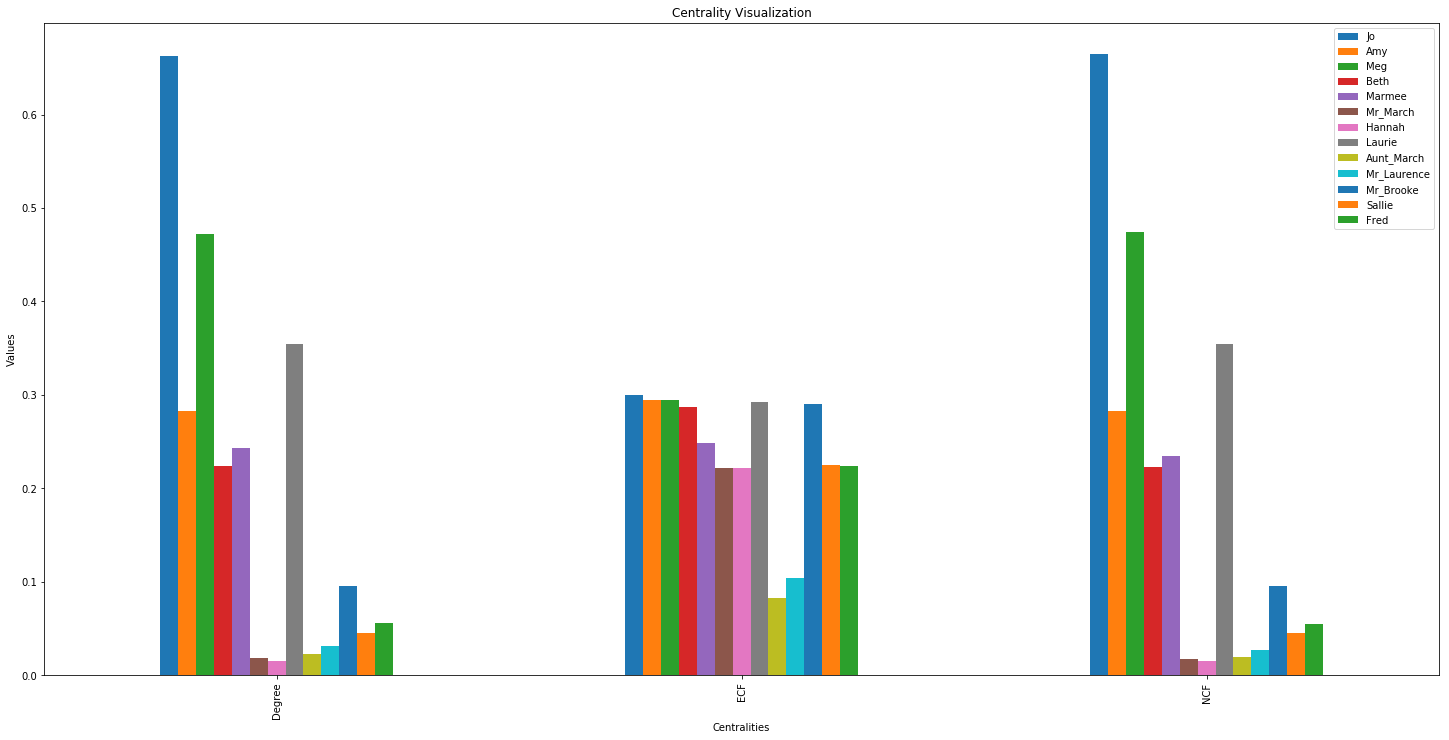

In [25]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Amy":list(df_2.loc[1]),
    "Meg":list(df_2.loc[2]),
    "Beth":list(df_2.loc[3]),
    "Marmee":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Aunt_March":list(df_2.loc[9]),
    "Mr_Laurence":list(df_2.loc[11]),
    "Mr_Brooke":list(df_2.loc[14]),
    "Sallie":list(df_2.loc[23]),
    "Fred":list(df_2.loc[33])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

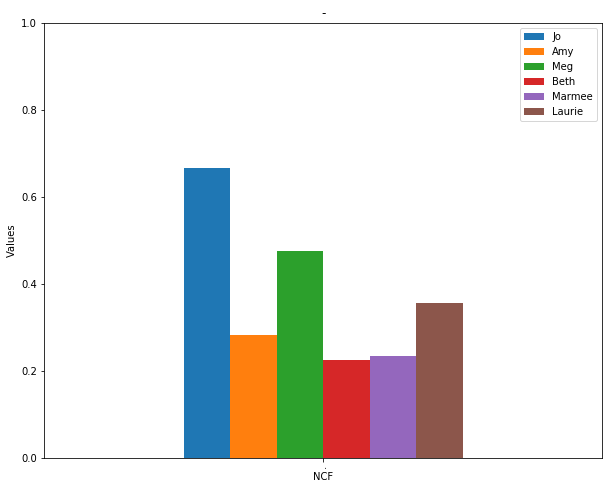

In [26]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[0][2],
    "Amy":df_2.loc[1][2],
    "Meg":df_2.loc[2][2],
    "Beth":df_2.loc[3][2],
    "Marmee":df_2.loc[4][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_7

Name: 
Type: Graph
Number of nodes: 59
Number of edges: 163
Average degree:   5.5254


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


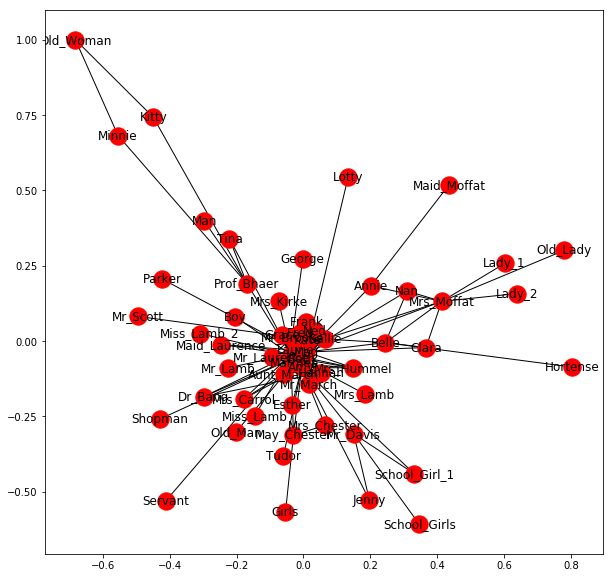

            Nodes  Degree       ECF           NCF
0              Jo  3232.0  0.969918  2.614463e-01
1             Amy  1382.0  0.942423  1.109266e-01
2             Meg  1937.0  0.934983  1.558538e-01
3            Beth   961.0  0.913634  7.679556e-02
4          Marmee  1112.0  0.798156  8.599717e-02
5        Mr_March    76.0  0.720686  5.744309e-03
6      Mrs_Hummel    19.0  0.505580  1.370970e-03
7          Hannah    64.0  0.719392  4.838150e-03
8          Laurie  1535.0  0.928514  1.227856e-01
9      Aunt_March   111.0  0.275756  7.785783e-03
10        Old_Man     7.0  0.001456  1.016231e-04
11    Mr_Laurence   130.0  0.345140  8.890650e-03
12        Servant     1.0  0.001294  1.998457e-05
13  Maid_Laurence    11.0  0.142164  5.609413e-04
14      Mr_Brooke   391.0  0.922044  3.127121e-02
15       Mr_Davis    26.0  0.005175  4.716516e-04
16          Jenny     4.0  0.004043  7.256179e-05
17  School_Girl_1     4.0  0.004043  7.256179e-05
18   School_Girls     3.0  0.000485  1.020155e-06


In [15]:
lw_7 = nx.read_weighted_edgelist('lw_s_7.txt', delimiter=',')
print(nx.info(lw_7))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_7)
plt.show()

#Weighted Centralities
w_deg = lw_7.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_7)  #ECF
w_ecf = weighted_ECF(lw_7, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_7) #NCF
w_ncf = weighted_cness(lw_7,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [16]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.705,0.303,0.710
1,0.301,0.295,0.301
2,0.422,0.292,0.423
3,0.210,0.286,0.208
4,0.243,0.249,0.233
5,0.017,0.225,0.016
6,0.004,0.158,0.004
7,0.014,0.225,0.013
8,0.335,0.290,0.333
9,0.024,0.086,0.021


Text(0, 0.5, 'Values')

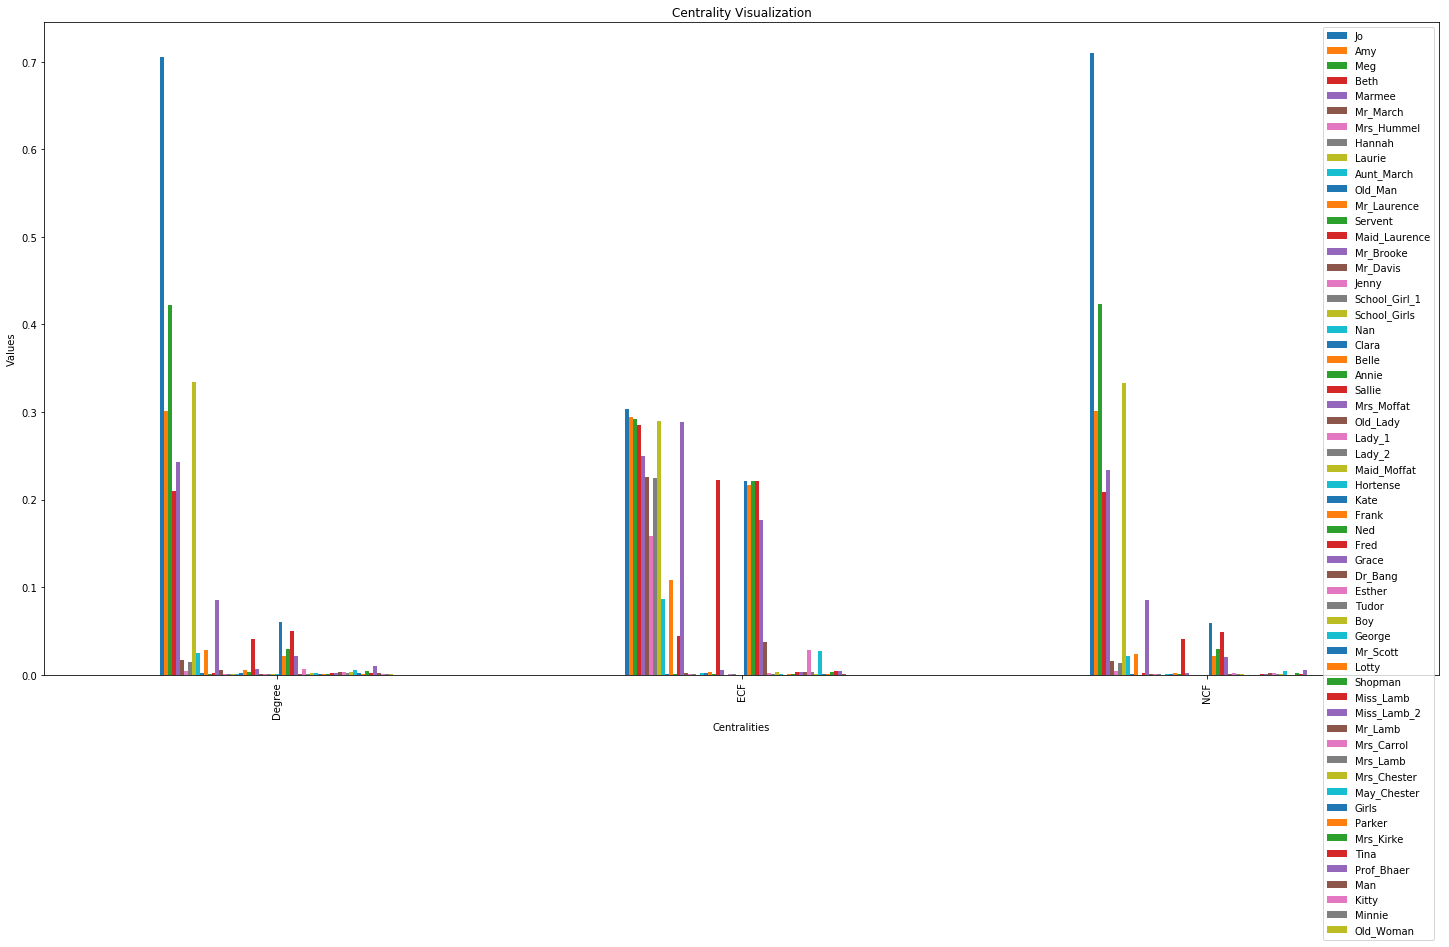

In [28]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Amy":list(df_2.loc[1]),
    "Meg":list(df_2.loc[2]),
    "Beth":list(df_2.loc[3]),
    "Marmee":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Mrs_Hummel":list(df_2.loc[6]),
    "Hannah":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Aunt_March":list(df_2.loc[9]),
    "Old_Man":list(df_2.loc[10]),
    "Mr_Laurence":list(df_2.loc[11]),
    "Servent":list(df_2.loc[12]),
    "Maid_Laurence":list(df_2.loc[13]),
    "Mr_Brooke":list(df_2.loc[14]),
    "Mr_Davis":list(df_2.loc[15]),
    "Jenny":list(df_2.loc[16]),
    "School_Girl_1":list(df_2.loc[17]),
    "School_Girls":list(df_2.loc[18]),
    "Nan":list(df_2.loc[19]),
    "Clara":list(df_2.loc[20]),
    "Belle":list(df_2.loc[21]),
    "Annie":list(df_2.loc[22]),
    "Sallie":list(df_2.loc[23]),
    "Mrs_Moffat":list(df_2.loc[24]),
    "Old_Lady":list(df_2.loc[25]),
    "Lady_1":list(df_2.loc[26]),
    "Lady_2":list(df_2.loc[27]),
    "Maid_Moffat":list(df_2.loc[28]),
    "Hortense":list(df_2.loc[29]),
    "Kate":list(df_2.loc[30]),
    "Frank":list(df_2.loc[31]),
    "Ned":list(df_2.loc[32]),
    "Fred":list(df_2.loc[33]),
    "Grace":list(df_2.loc[34]),
    "Dr_Bang":list(df_2.loc[35]),
    "Esther":list(df_2.loc[36]),
    "Tudor":list(df_2.loc[37]),
    "Boy":list(df_2.loc[38]),
    "George":list(df_2.loc[39]),
    "Mr_Scott":list(df_2.loc[40]),
    "Lotty":list(df_2.loc[41]),
    "Shopman":list(df_2.loc[42]),
    "Miss_Lamb":list(df_2.loc[43]),
    "Miss_Lamb_2":list(df_2.loc[44]),
    "Mr_Lamb":list(df_2.loc[45]),
    "Mrs_Carrol":list(df_2.loc[46]),
    "Mrs_Lamb":list(df_2.loc[47]),
    "Mrs_Chester":list(df_2.loc[48]),
    "May_Chester":list(df_2.loc[49]),
    "Girls":list(df_2.loc[50]),
    "Parker":list(df_2.loc[51]),
    "Mrs_Kirke":list(df_2.loc[52]),
    "Tina":list(df_2.loc[53]),
    "Prof_Bhaer":list(df_2.loc[54]),
    "Man":list(df_2.loc[55]),
    "Kitty":list(df_2.loc[56]),
    "Minnie":list(df_2.loc[57]),
    "Old_Woman":list(df_2.loc[58])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

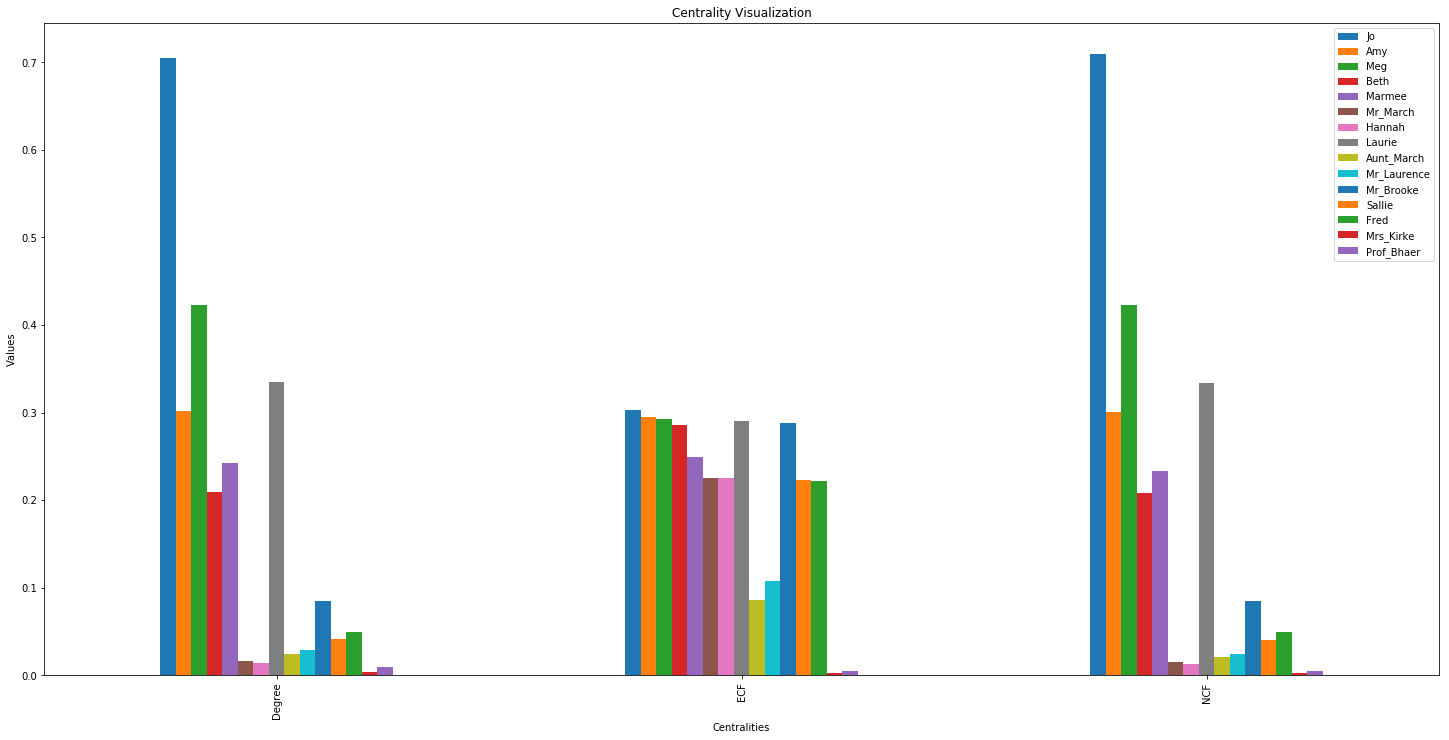

In [29]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Amy":list(df_2.loc[1]),
    "Meg":list(df_2.loc[2]),
    "Beth":list(df_2.loc[3]),
    "Marmee":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Aunt_March":list(df_2.loc[9]),
    "Mr_Laurence":list(df_2.loc[11]),
    "Mr_Brooke":list(df_2.loc[14]),
    "Sallie":list(df_2.loc[23]),
    "Fred":list(df_2.loc[33]),
    "Mrs_Kirke":list(df_2.loc[52]),
    "Prof_Bhaer":list(df_2.loc[54])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

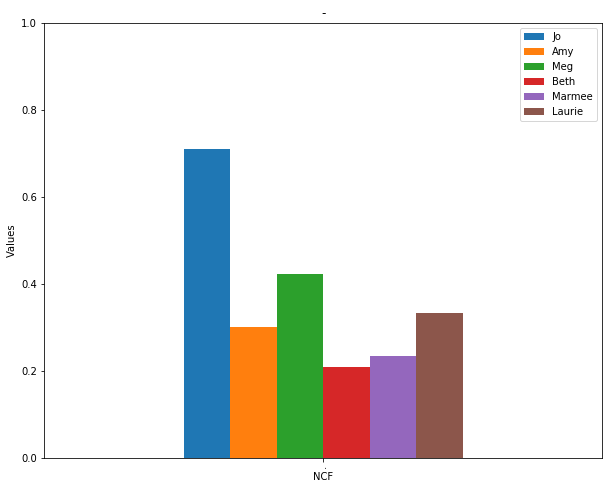

In [30]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[0][2],
    "Amy":df_2.loc[1][2],
    "Meg":df_2.loc[2][2],
    "Beth":df_2.loc[3][2],
    "Marmee":df_2.loc[4][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_8

Name: 
Type: Graph
Number of nodes: 61
Number of edges: 168
Average degree:   5.5082


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


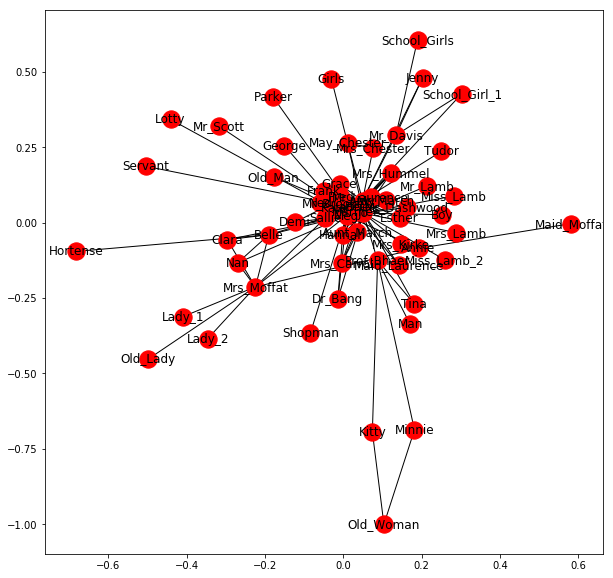

            Nodes  Degree       ECF           NCF
0              Jo  3517.0  0.969005  2.618719e-01
1             Amy  1480.0  0.925997  1.090599e-01
2             Meg  2084.0  0.922586  1.538431e-01
3            Beth  1032.0  0.907163  7.568400e-02
4          Marmee  1185.0  0.801127  8.433747e-02
5        Mr_March    76.0  0.713777  5.287801e-03
6      Mrs_Hummel    19.0  0.489841  1.256553e-03
7          Hannah    64.0  0.712591  4.453589e-03
8          Laurie  1766.0  0.920807  1.296300e-01
9      Aunt_March   111.0  0.266499  7.166362e-03
10        Old_Man     7.0  0.001335  9.106395e-05
11    Mr_Laurence   181.0  0.352810  1.147471e-02
12        Servant     1.0  0.001186  1.934325e-05
13  Maid_Laurence    11.0  0.147857  5.197826e-04
14      Mr_Brooke   461.0  0.918286  3.384901e-02
15       Mr_Davis    26.0  0.005487  4.231543e-04
16          Jenny     4.0  0.004449  6.510066e-05
17  School_Girl_1     4.0  0.004449  6.510066e-05
18   School_Girls     3.0  0.000445  8.577452e-07


In [17]:
lw_8 = nx.read_weighted_edgelist('lw_s_8.txt', delimiter=',')
print(nx.info(lw_8))

plt.figure(figsize = (10,10))
nx.draw_networkx(lw_8)
plt.show()

#Weighted Centralities
w_deg = lw_8.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_8)  #ECF
w_ecf = weighted_ECF(lw_8, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_8) #NCF
w_ncf = weighted_cness(lw_8,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [18]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.704,0.306,0.709
1,0.296,0.292,0.295
2,0.417,0.291,0.417
3,0.207,0.286,0.205
4,0.237,0.253,0.228
5,0.015,0.225,0.014
6,0.004,0.154,0.003
7,0.013,0.225,0.012
8,0.353,0.290,0.351
9,0.022,0.084,0.019


Text(0, 0.5, 'Values')

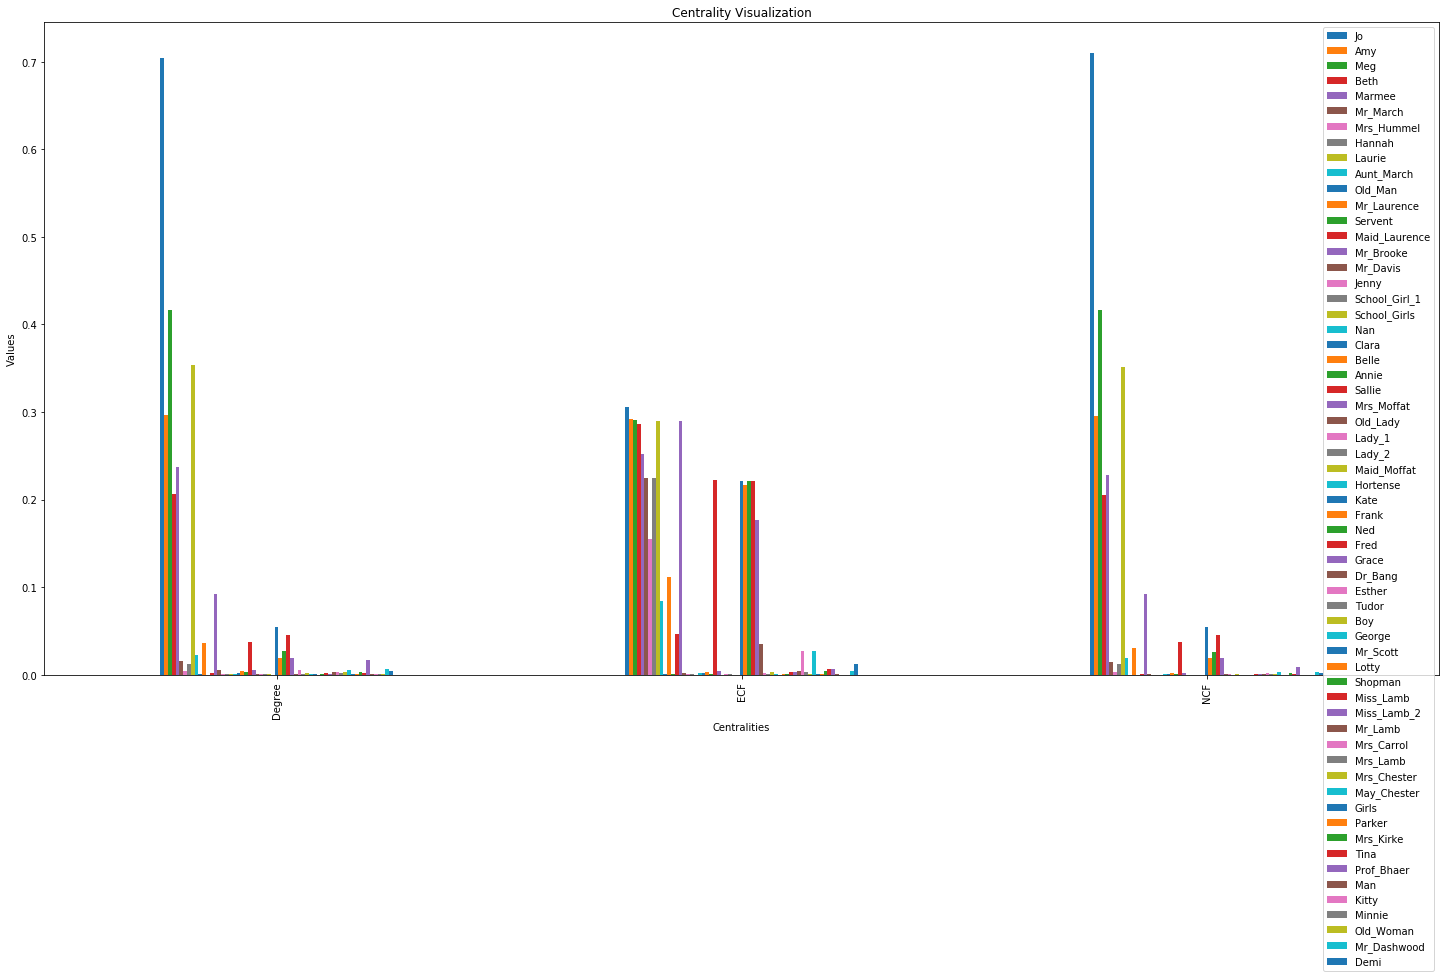

In [32]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Amy":list(df_2.loc[1]),
    "Meg":list(df_2.loc[2]),
    "Beth":list(df_2.loc[3]),
    "Marmee":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Mrs_Hummel":list(df_2.loc[6]),
    "Hannah":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Aunt_March":list(df_2.loc[9]),
    "Old_Man":list(df_2.loc[10]),
    "Mr_Laurence":list(df_2.loc[11]),
    "Servent":list(df_2.loc[12]),
    "Maid_Laurence":list(df_2.loc[13]),
    "Mr_Brooke":list(df_2.loc[14]),
    "Mr_Davis":list(df_2.loc[15]),
    "Jenny":list(df_2.loc[16]),
    "School_Girl_1":list(df_2.loc[17]),
    "School_Girls":list(df_2.loc[18]),
    "Nan":list(df_2.loc[19]),
    "Clara":list(df_2.loc[20]),
    "Belle":list(df_2.loc[21]),
    "Annie":list(df_2.loc[22]),
    "Sallie":list(df_2.loc[23]),
    "Mrs_Moffat":list(df_2.loc[24]),
    "Old_Lady":list(df_2.loc[25]),
    "Lady_1":list(df_2.loc[26]),
    "Lady_2":list(df_2.loc[27]),
    "Maid_Moffat":list(df_2.loc[28]),
    "Hortense":list(df_2.loc[29]),
    "Kate":list(df_2.loc[30]),
    "Frank":list(df_2.loc[31]),
    "Ned":list(df_2.loc[32]),
    "Fred":list(df_2.loc[33]),
    "Grace":list(df_2.loc[34]),
    "Dr_Bang":list(df_2.loc[35]),
    "Esther":list(df_2.loc[36]),
    "Tudor":list(df_2.loc[37]),
    "Boy":list(df_2.loc[38]),
    "George":list(df_2.loc[39]),
    "Mr_Scott":list(df_2.loc[40]),
    "Lotty":list(df_2.loc[41]),
    "Shopman":list(df_2.loc[42]),
    "Miss_Lamb":list(df_2.loc[43]),
    "Miss_Lamb_2":list(df_2.loc[44]),
    "Mr_Lamb":list(df_2.loc[45]),
    "Mrs_Carrol":list(df_2.loc[46]),
    "Mrs_Lamb":list(df_2.loc[47]),
    "Mrs_Chester":list(df_2.loc[48]),
    "May_Chester":list(df_2.loc[49]),
    "Girls":list(df_2.loc[50]),
    "Parker":list(df_2.loc[51]),
    "Mrs_Kirke":list(df_2.loc[52]),
    "Tina":list(df_2.loc[53]),
    "Prof_Bhaer":list(df_2.loc[54]),
    "Man":list(df_2.loc[55]),
    "Kitty":list(df_2.loc[56]),
    "Minnie":list(df_2.loc[57]),
    "Old_Woman":list(df_2.loc[58]),
    "Mr_Dashwood":list(df_2.loc[59]),
    "Demi":list(df_2.loc[60])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

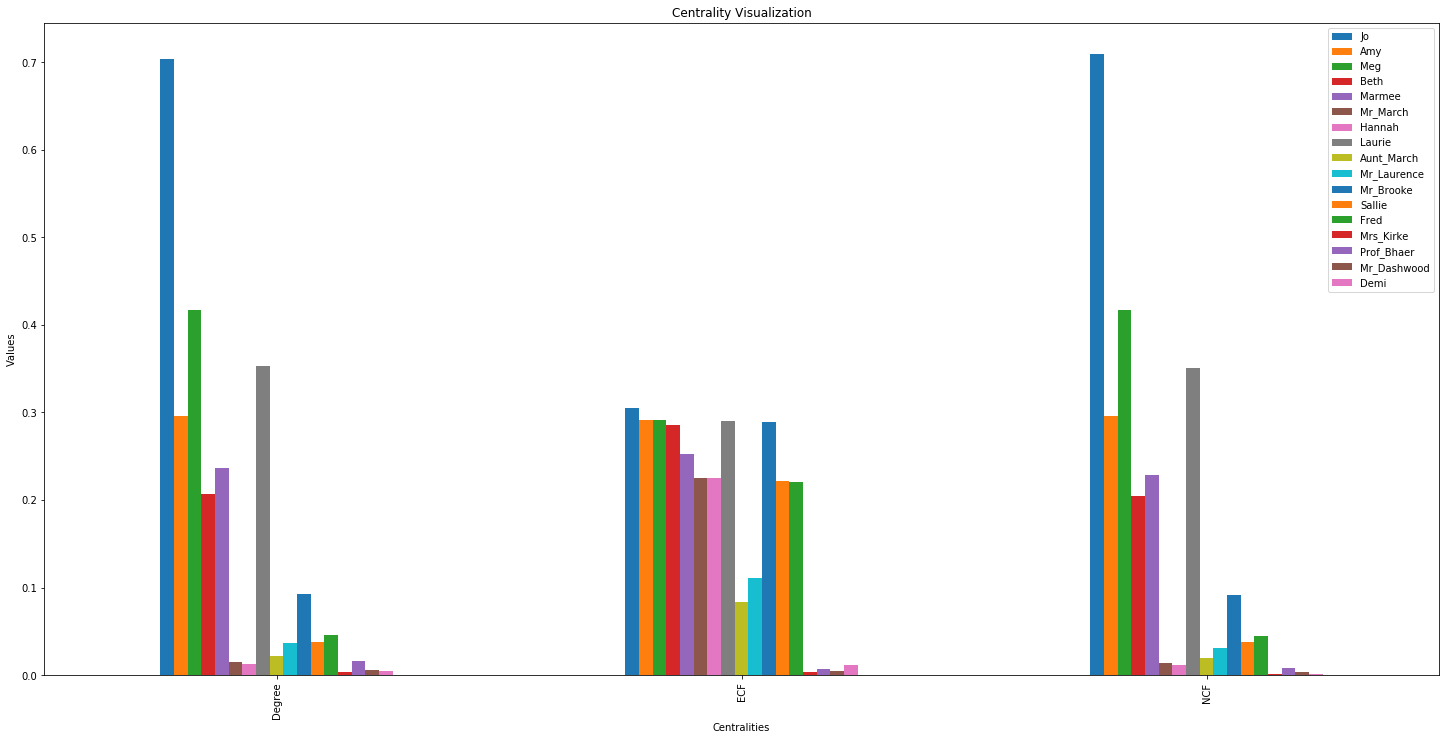

In [33]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Amy":list(df_2.loc[1]),
    "Meg":list(df_2.loc[2]),
    "Beth":list(df_2.loc[3]),
    "Marmee":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Aunt_March":list(df_2.loc[9]),
    "Mr_Laurence":list(df_2.loc[11]),
    "Mr_Brooke":list(df_2.loc[14]),
    "Sallie":list(df_2.loc[23]),
    "Fred":list(df_2.loc[33]),
    "Mrs_Kirke":list(df_2.loc[52]),
    "Prof_Bhaer":list(df_2.loc[54]),
    "Mr_Dashwood":list(df_2.loc[59]),
    "Demi":list(df_2.loc[60])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

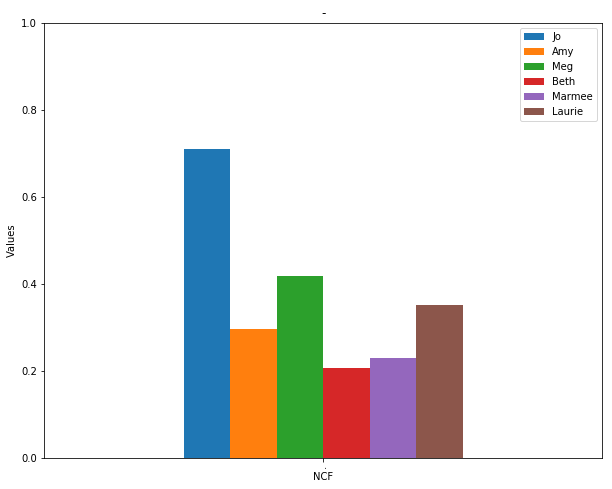

In [34]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[0][2],
    "Amy":df_2.loc[1][2],
    "Meg":df_2.loc[2][2],
    "Beth":df_2.loc[3][2],
    "Marmee":df_2.loc[4][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_9

Name: 
Type: Graph
Number of nodes: 64
Number of edges: 180
Average degree:   5.6250


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


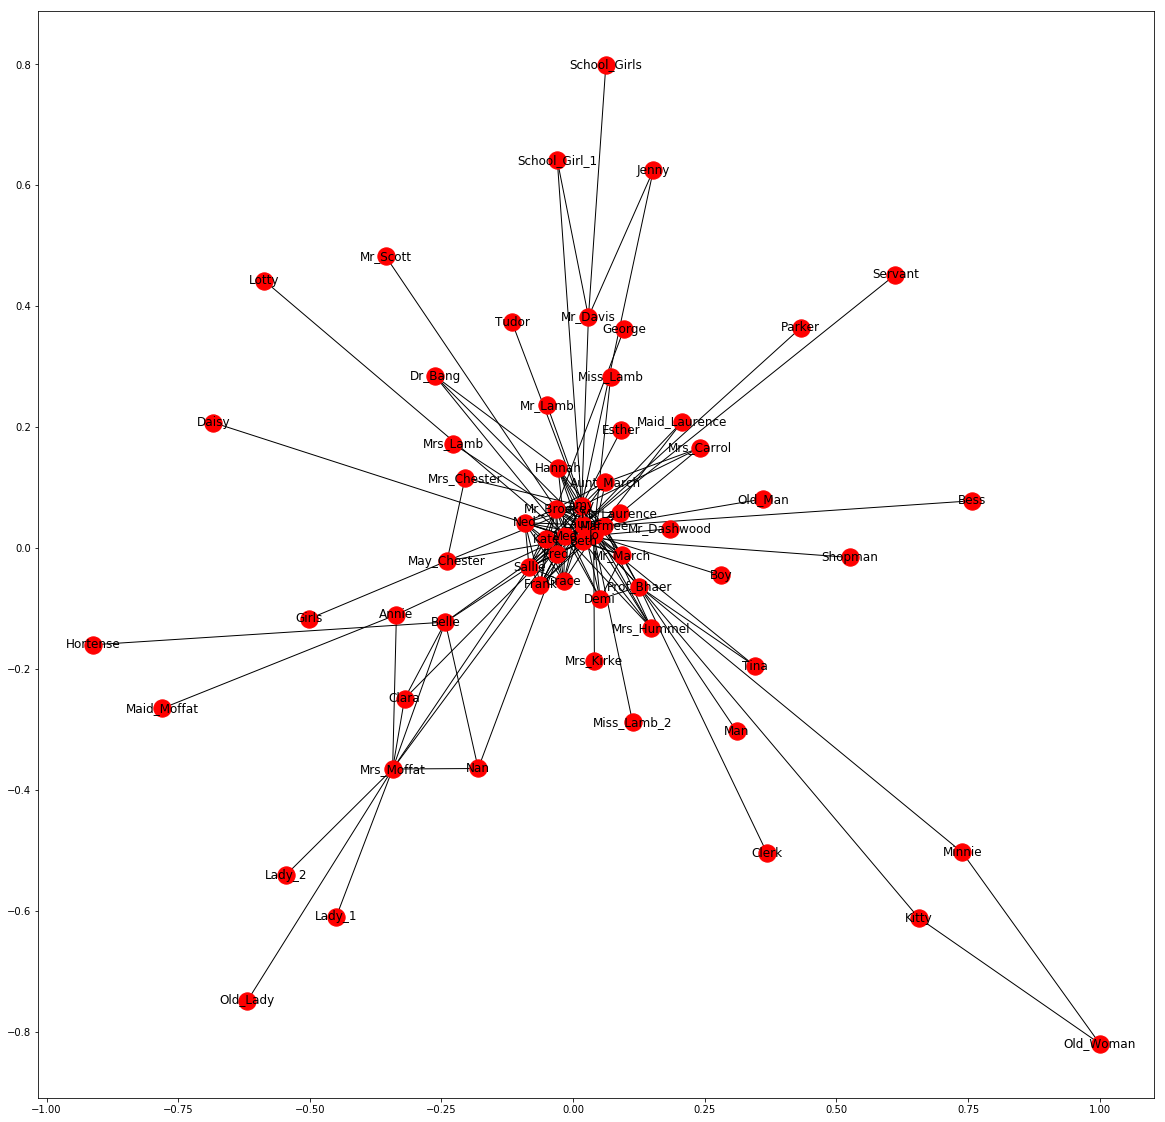

            Nodes  Degree       ECF           NCF
0              Jo  4149.0  0.975563  2.685326e-01
1             Amy  1850.0  0.906495  1.182060e-01
2             Meg  2139.0  0.933891  1.370255e-01
3            Beth  1056.0  0.893376  6.719375e-02
4          Marmee  1307.0  0.829839  8.131640e-02
5        Mr_March   145.0  0.756656  8.855822e-03
6      Mrs_Hummel    19.0  0.453248  1.099443e-03
7          Hannah    75.0  0.714855  4.546479e-03
8          Laurie  2305.0  0.941994  1.475261e-01
9      Aunt_March   111.0  0.243987  6.268819e-03
10        Old_Man     7.0  0.001158  7.555753e-05
11    Mr_Laurence   206.0  0.561029  1.237521e-02
12        Servant     1.0  0.002701  1.889972e-05
13  Maid_Laurence    11.0  0.158328  4.762068e-04
14      Mr_Brooke   461.0  0.897235  2.937176e-02
15       Mr_Davis    26.0  0.005273  3.969851e-04
16          Jenny     4.0  0.004373  6.107464e-05
17  School_Girl_1     4.0  0.004373  6.107464e-05
18   School_Girls     3.0  0.000386  6.451546e-07


In [19]:
lw_9 = nx.read_weighted_edgelist('lw_s_9.txt', delimiter=',')
print(nx.info(lw_9))

plt.figure(figsize = (20,20))
nx.draw_networkx(lw_9)
plt.show()

#Weighted Centralities
w_deg = lw_9.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_9)  #ECF
w_ecf = weighted_ECF(lw_9, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_9) #NCF
w_ncf = weighted_cness(lw_9,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [20]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.712,0.302,0.718
1,0.318,0.281,0.316
2,0.367,0.289,0.366
3,0.181,0.277,0.180
4,0.224,0.257,0.217
5,0.025,0.234,0.024
6,0.003,0.140,0.003
7,0.013,0.221,0.012
8,0.396,0.292,0.394
9,0.019,0.076,0.017


Text(0, 0.5, 'Values')

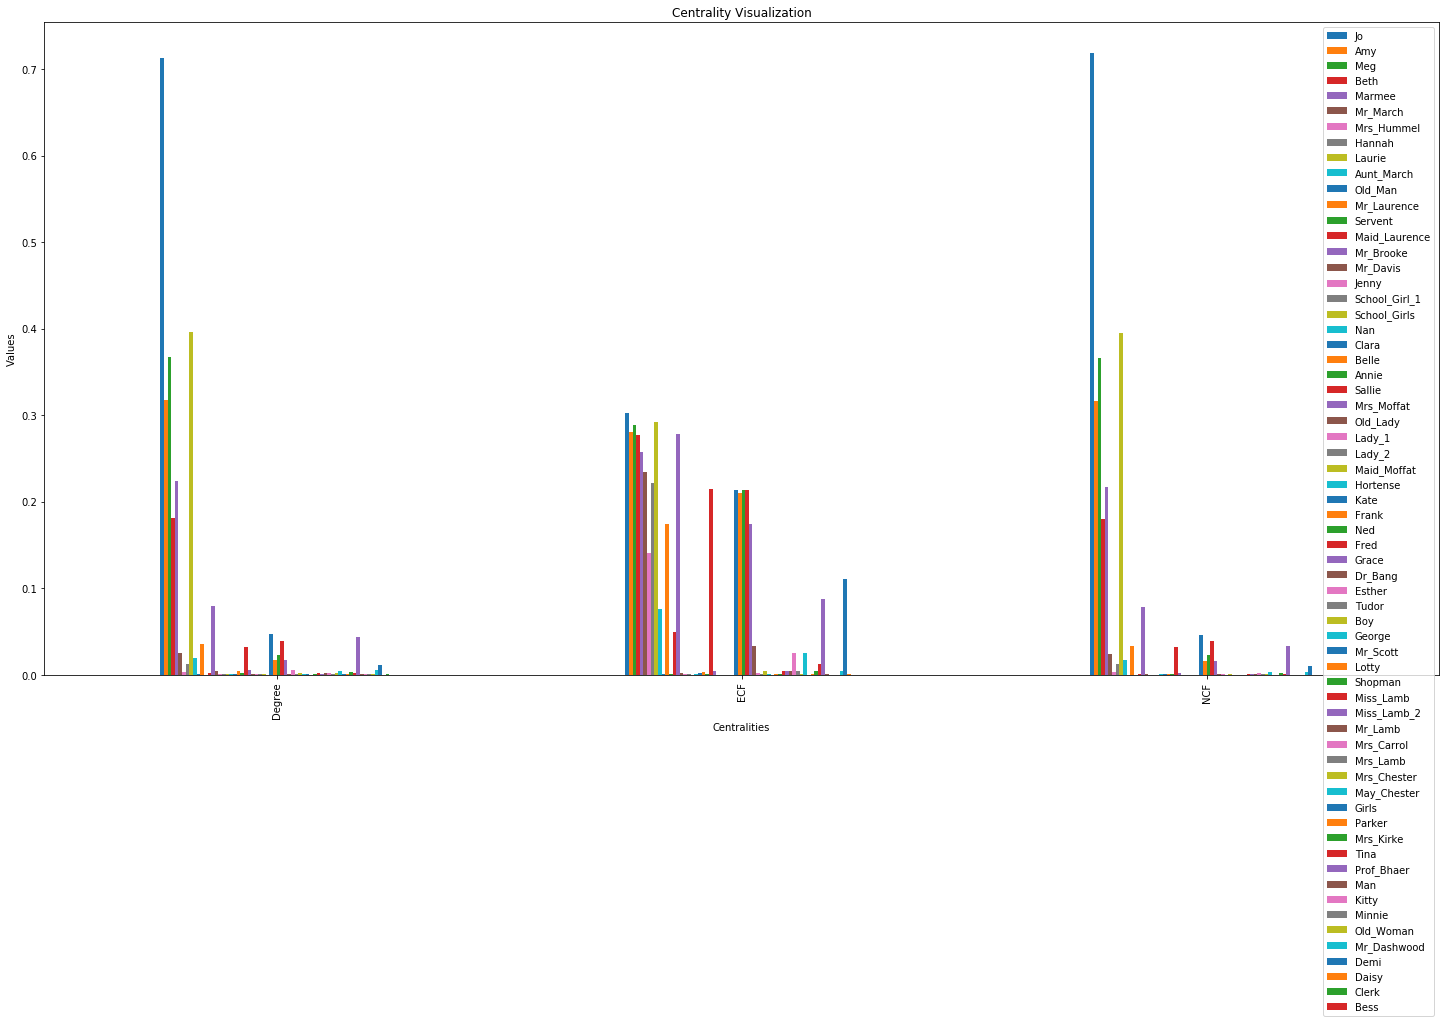

In [36]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Amy":list(df_2.loc[1]),
    "Meg":list(df_2.loc[2]),
    "Beth":list(df_2.loc[3]),
    "Marmee":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Mrs_Hummel":list(df_2.loc[6]),
    "Hannah":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Aunt_March":list(df_2.loc[9]),
    "Old_Man":list(df_2.loc[10]),
    "Mr_Laurence":list(df_2.loc[11]),
    "Servent":list(df_2.loc[12]),
    "Maid_Laurence":list(df_2.loc[13]),
    "Mr_Brooke":list(df_2.loc[14]),
    "Mr_Davis":list(df_2.loc[15]),
    "Jenny":list(df_2.loc[16]),
    "School_Girl_1":list(df_2.loc[17]),
    "School_Girls":list(df_2.loc[18]),
    "Nan":list(df_2.loc[19]),
    "Clara":list(df_2.loc[20]),
    "Belle":list(df_2.loc[21]),
    "Annie":list(df_2.loc[22]),
    "Sallie":list(df_2.loc[23]),
    "Mrs_Moffat":list(df_2.loc[24]),
    "Old_Lady":list(df_2.loc[25]),
    "Lady_1":list(df_2.loc[26]),
    "Lady_2":list(df_2.loc[27]),
    "Maid_Moffat":list(df_2.loc[28]),
    "Hortense":list(df_2.loc[29]),
    "Kate":list(df_2.loc[30]),
    "Frank":list(df_2.loc[31]),
    "Ned":list(df_2.loc[32]),
    "Fred":list(df_2.loc[33]),
    "Grace":list(df_2.loc[34]),
    "Dr_Bang":list(df_2.loc[35]),
    "Esther":list(df_2.loc[36]),
    "Tudor":list(df_2.loc[37]),
    "Boy":list(df_2.loc[38]),
    "George":list(df_2.loc[39]),
    "Mr_Scott":list(df_2.loc[40]),
    "Lotty":list(df_2.loc[41]),
    "Shopman":list(df_2.loc[42]),
    "Miss_Lamb":list(df_2.loc[43]),
    "Miss_Lamb_2":list(df_2.loc[44]),
    "Mr_Lamb":list(df_2.loc[45]),
    "Mrs_Carrol":list(df_2.loc[46]),
    "Mrs_Lamb":list(df_2.loc[47]),
    "Mrs_Chester":list(df_2.loc[48]),
    "May_Chester":list(df_2.loc[49]),
    "Girls":list(df_2.loc[50]),
    "Parker":list(df_2.loc[51]),
    "Mrs_Kirke":list(df_2.loc[52]),
    "Tina":list(df_2.loc[53]),
    "Prof_Bhaer":list(df_2.loc[54]),
    "Man":list(df_2.loc[55]),
    "Kitty":list(df_2.loc[56]),
    "Minnie":list(df_2.loc[57]),
    "Old_Woman":list(df_2.loc[58]),
    "Mr_Dashwood":list(df_2.loc[59]),
    "Demi":list(df_2.loc[60]),
    "Daisy":list(df_2.loc[61]),
    "Clerk":list(df_2.loc[62]),
    "Bess":list(df_2.loc[63])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

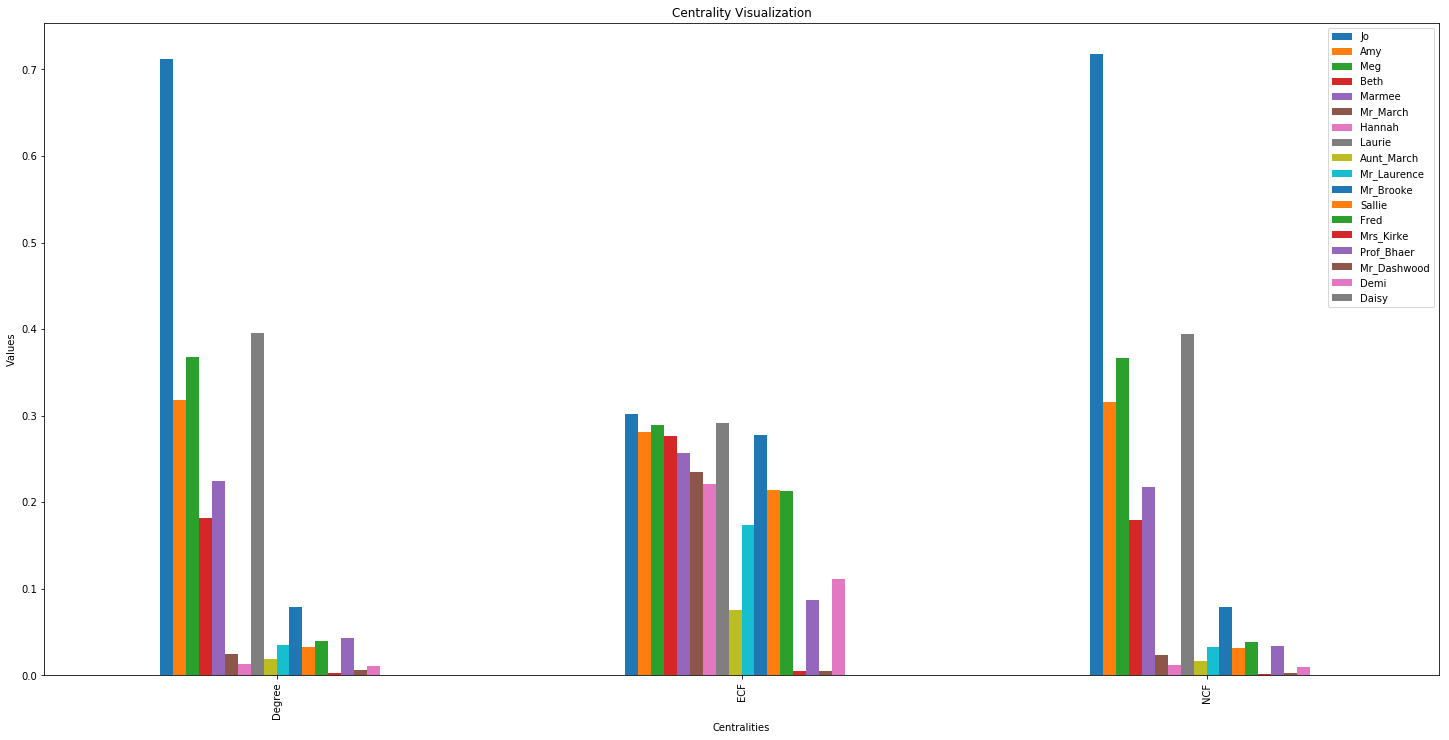

In [37]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Amy":list(df_2.loc[1]),
    "Meg":list(df_2.loc[2]),
    "Beth":list(df_2.loc[3]),
    "Marmee":list(df_2.loc[4]),
    "Mr_March":list(df_2.loc[5]),
    "Hannah":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Aunt_March":list(df_2.loc[9]),
    "Mr_Laurence":list(df_2.loc[11]),
    "Mr_Brooke":list(df_2.loc[14]),
    "Sallie":list(df_2.loc[23]),
    "Fred":list(df_2.loc[33]),
    "Mrs_Kirke":list(df_2.loc[52]),
    "Prof_Bhaer":list(df_2.loc[54]),
    "Mr_Dashwood":list(df_2.loc[59]),
    "Demi":list(df_2.loc[60]),
    "Daisy":list(df_2.loc[61])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

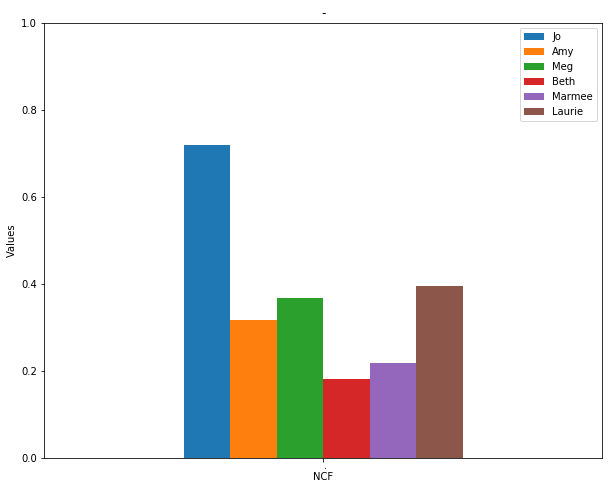

In [38]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[0][2],
    "Amy":df_2.loc[1][2],
    "Meg":df_2.loc[2][2],
    "Beth":df_2.loc[3][2],
    "Marmee":df_2.loc[4][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

In [39]:
# Let's create a Dataframe using lists
timestamp = ['t1', 't2', 't3', 't4', 't5', 't6', 't7', 't8', 't9']

jo = [0.747739,0.682151,0.650966,0.662972,0.676323,0.664979,7.095834e-01,7.094857e-01,7.180047e-01]
amy = [0.284791,0.327919,0.295461,0.299204,0.277205,0.282885,3.010624e-01,2.954744e-01,3.160601e-01]
meg = [0.449093,0.502929,0.479545,0.455006,0.466123,0.474576,4.229980e-01,4.168049e-01,3.663800e-01]
beth = [0.260356,0.245433,0.260916,0.255099,0.237602,0.223224,2.084285e-01,2.050496e-01,1.796632e-01]
marmee = [0.273837,0.278853,0.208071,0.237020,0.228991,0.234137,2.334023e-01,2.284943e-01,2.174245e-01]
laurie = [0.120163,0.185652,0.344622,0.345942,0.343459,0.354391,3.332485e-01,3.512048e-01,3.944566e-01]

# Now, create a pandas dataframe using above lists
df_pop_density = pd.DataFrame(
    {'Timestamp' : timestamp, 'Jo' : jo,'Amy' : amy, 'Meg' : meg, 'Beth' : beth, 'Marmee' : marmee, 'Laurie' : laurie})
df_pop_density

,Timestamp,Jo,Amy,Meg,Beth,Marmee,Laurie
0,t1,0.747739,0.284791,0.449093,0.260356,0.273837,0.120163
1,t2,0.682151,0.327919,0.502929,0.245433,0.278853,0.185652
2,t3,0.650966,0.295461,0.479545,0.260916,0.208071,0.344622
3,t4,0.662972,0.299204,0.455006,0.255099,0.237020,0.345942
4,t5,0.676323,0.277205,0.466123,0.237602,0.228991,0.343459
5,t6,0.664979,0.282885,0.474576,0.223224,0.234137,0.354391
6,t7,0.709583,0.301062,0.422998,0.208428,0.233402,0.333249
7,t8,0.709486,0.295474,0.416805,0.205050,0.228494,0.351205
8,t9,0.718005,0.316060,0.366380,0.179663,0.217424,0.394457


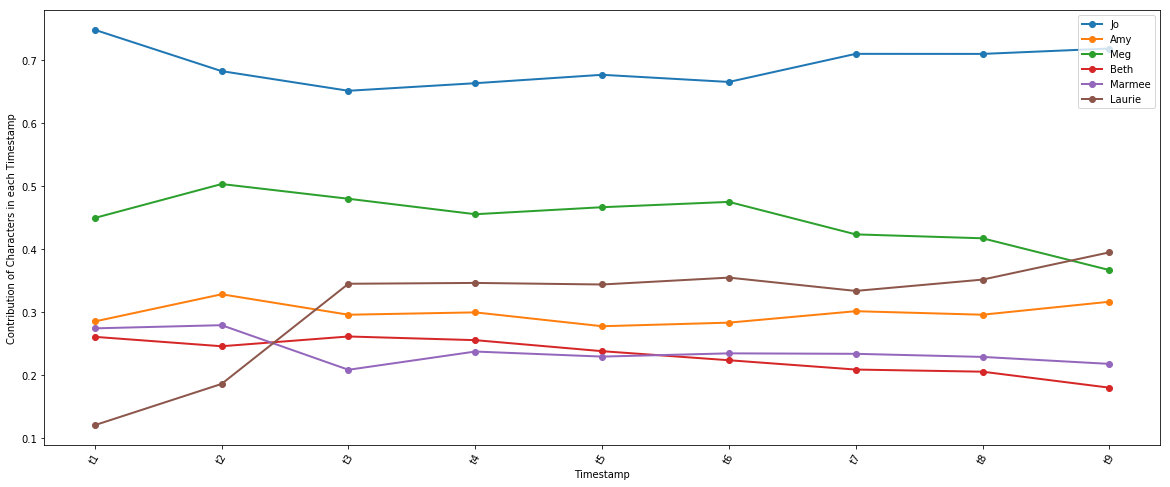

In [43]:
# Creating figure and axis objects using subplots()
fig, ax = plt.subplots(figsize=[20, 8])

ax.plot(df_pop_density['Timestamp'], df_pop_density['Jo'], marker='o', linewidth=2, label='Jo')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Amy'], marker='o', linewidth=2, label='Amy')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Meg'], marker='o', linewidth=2, label='Meg')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Beth'], marker='o', linewidth=2, label='Beth')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Marmee'], marker='o', linewidth=2, label='Marmee')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Laurie'], marker='o', linewidth=2, label='Laurie')
plt.xticks(rotation=60)
ax.set_xlabel('Timestamp')
ax.set_ylabel('Contribution of Characters in each Timestamp')
plt.legend()
plt.show()

In [12]:
# Reevaluate the remaining part

In [62]:
# Let's create a Dataframe using lists
timestamp = ['t1', 't2', 't3', 't4']

apoorva_yogmaya = [0.8181818181818182,1.4729064039408866,1.6794258373205742,1.3652450090744102]

apoorva_mrinmoyee = [0.5454545454545454,1.379310344827586,2.0050125313283207,1.4123376623376624]

# Now, create a pandas dataframe using above lists
df_pop_density = pd.DataFrame(
    {'Timestamp' : timestamp, 'Correlation_With_Yogmaya' : apoorva_yogmaya, 'Correlation_With_Mrinmoyee' : apoorva_mrinmoyee})

df_pop_density

,Timestamp,Correlation_With_Yogmaya,Correlation_With_Mrinmoyee
0,t1,0.818182,0.545455
1,t2,1.472906,1.379310
2,t3,1.679426,2.005013
3,t4,1.365245,1.412338


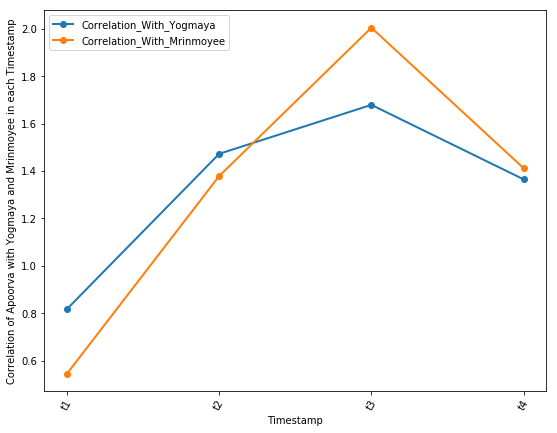

In [63]:
# Creating figure and axis objects using subplots()
fig, ax = plt.subplots(figsize=[9, 7])

ax.plot(df_pop_density['Timestamp'], df_pop_density['Correlation_With_Yogmaya'], marker='o', linewidth=2, label='Correlation_With_Yogmaya')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Correlation_With_Mrinmoyee'], marker='o', linewidth=2, label='Correlation_With_Mrinmoyee')
plt.xticks(rotation=60)
ax.set_xlabel('Timestamp')
ax.set_ylabel('Correlation of Apoorva with Yogmaya and Mrinmoyee in each Timestamp')
plt.legend()
plt.show()